# SECOM 데이터 분석 파이프라인

## 라이브러리 import

In [35]:
import os
import tempfile
import ast


def get_env_int(name, default):
    try:
        return int(os.environ.get(name, default))
    except (TypeError, ValueError):
        return int(default)


CPU_THREADS = get_env_int("SECOM_CPU_THREADS", os.cpu_count() or 1)
OUTER_N_JOBS = get_env_int("SECOM_OUTER_N_JOBS", min(9, CPU_THREADS))
MODEL_N_JOBS = get_env_int("SECOM_MODEL_N_JOBS", max(1, CPU_THREADS // max(1, OUTER_N_JOBS)))
BLAS_THREADS = get_env_int("SECOM_BLAS_THREADS", MODEL_N_JOBS)

for thread_env in [
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
]:
    os.environ.setdefault(thread_env, str(BLAS_THREADS))

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (
    SelectKBest, chi2, f_classif, mutual_info_classif,
    SelectFpr, SelectFdr, SelectFwe
)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    f1_score, fbeta_score, roc_auc_score, roc_curve,
    confusion_matrix, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError("xgboost 설치하세요.") from e

def resolve_base_dir():
    search_roots = [Path.cwd(), *Path.cwd().parents, Path.home() / "secom_project" / "data2"]

    for root in search_roots:
        if (root / "kfold" / "fold1_train.xlsx").exists():
            return root

        for candidate in root.glob("**/kfold/fold1_train.xlsx"):
            return candidate.parent.parent


base_dir = resolve_base_dir()

joblib_temp_dir = Path(tempfile.gettempdir()) / "secom_joblib_tmp"
joblib_temp_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("JOBLIB_TEMP_FOLDER", str(joblib_temp_dir))

raw_dir = base_dir / "kfold"
inpaintknn_dir = base_dir / "kfold_inpaintknn"
mice_dir = base_dir / "kfold_mice"
missforest_dir = base_dir / "kfold_missforest"
checkpoint_dir = base_dir / "checkpoint"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_FEATURES_SELECT = 50
POSITIVE_CLASS = 1
LABEL_COL = "Column1"

N_JOBS = OUTER_N_JOBS
CHECKPOINT_EVERY = 50
INNER_THRESHOLD_VALID_SIZE = 0.25
THRESHOLD_OPTIMIZE_METRIC = "f2"
TUNE_HYPERPARAMETERS = True
MAX_PARAM_CANDIDATES = {
    "knn": 10,
    "svm": 12,
    "rf": 18,
    "lr": 8,
    "hgb": 18,
    "xgboost": 24,
}


### 공통 확인 함수

표 + 그래프 확인 위한 함수 정의

In [71]:
try:
    from IPython.display import display, Image as IPythonImage
except Exception:
    display = print
    IPythonImage = None


def show_df_overview(df, name="DataFrame", max_rows=5):
    print()
    print(f"[{name}] shape = {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    print(f"- duplicated rows: {df.duplicated().sum():,}")
    print(f"- total missing values: {df.isna().sum().sum():,}")

    overview = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "n_unique": df.nunique(dropna=True),
    }).sort_values(["missing_count", "n_unique"], ascending=[False, False])

    display(overview.head(15))
    display(df.head(max_rows))


def show_label_balance(y, name="label"):
    counts = pd.Series(y, name=name).value_counts(dropna=False).sort_index()
    ratio = counts / counts.sum()
    label_df = pd.DataFrame({"count": counts, "ratio": ratio})
    display(label_df)

    ax = label_df["count"].plot(kind="bar", figsize=(4, 3), title=f"{name} distribution")
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()


## 1. 실험 설정 및 임계값 로드


In [37]:
threshold_path = base_dir / "threshold_results_valid.csv"

IMPUTATION_NAME_MAP = {
    "raw": "raw",
    "raw+M": "raw_M",
    "knn": "inpaintknn",
    "knn+M": "inpaintknn_M",
    "mice": "mice",
    "mice+M": "mice_M",
    "mean": "mean",
    "mean+M": "mean_M",
    "missforest": "missforest",
    "missforest+M": "missforest_M",
    "M_only": "M_only",
}

BALANCING_NAME_MAP = {
    "raw": "raw",
    "SMOTE": "smote",
    "smote": "smote",
}

FEATURE_SELECTION_NAME_MAP = {
    "anova": "f_classif",
    "ANOVA": "f_classif",
    "f_classif": "f_classif",
    "chi2": "chi2",
    "fdr": "fdr",
    "fpr": "fpr",
    "fwe": "fwe",
    "mutual_info": "mutual_info",
    "raw": "raw",
}

MODEL_NAME_MAP = {
    "KNN": "knn",
    "SVM": "svm",
    "RF": "rf",
    "LR": "lr",
    "XGBoost": "xgboost",
    "HGB": "hgb",
    "knn": "knn",
    "svm": "svm",
    "rf": "rf",
    "lr": "lr",
    "xgboost": "xgboost",
    "hgb": "hgb",
}

def load_threshold_table(threshold_csv_path):
    """
    threshold_results_valid.csv를 읽고 코드 내부 이름으로 매핑한다.
    필요한 컬럼:
    - imputation
    - balancing
    - feature_selection
    - model
    - best_threshold
    """
    threshold_csv_path = Path(threshold_csv_path)

    if not threshold_csv_path.exists():
        raise FileNotFoundError(
            f"threshold 파일 없음: {threshold_csv_path}\n"
            "base_dir 아래에 threshold_results_valid.csv 파일을 넣어주세요."
        )

    df = pd.read_csv(threshold_csv_path)

    required_cols = ["imputation", "balancing", "feature_selection", "model", "best_threshold"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"threshold 파일에 필수 컬럼이 없습니다: {missing_cols}\n"
            f"현재 컬럼: {list(df.columns)}"
        )

    df = df.copy()

    # 문자열 컬럼 공백 제거
    for col in ["imputation", "balancing", "feature_selection", "model"]:
        df[col] = df[col].astype(str).str.strip()

    df["pipeline"] = df["imputation"].map(IMPUTATION_NAME_MAP)
    df["balancing_code"] = df["balancing"].map(BALANCING_NAME_MAP)
    df["feature_selection_code"] = df["feature_selection"].map(FEATURE_SELECTION_NAME_MAP)
    df["model_code"] = df["model"].map(MODEL_NAME_MAP)

    mapping_cols = ["pipeline", "balancing_code", "feature_selection_code", "model_code"]
    failed_map = df[df[mapping_cols].isna().any(axis=1)]

    if len(failed_map) > 0:
        print("\n오류: threshold 이름 매핑 실패 행:")
        print(
            failed_map[
                ["imputation", "balancing", "feature_selection", "model"]
            ].drop_duplicates().to_string(index=False)
        )
        raise ValueError("threshold_results_valid.csv의 이름이 코드 이름과 매핑되지 않습니다.")

    df["best_threshold"] = pd.to_numeric(df["best_threshold"], errors="coerce")
    invalid_threshold = df[df["best_threshold"].isna()]

    if len(invalid_threshold) > 0:
        print("\n오류: best_threshold 숫자 변환 실패 행:")
        print(
            invalid_threshold[
                ["imputation", "balancing", "feature_selection", "model", "best_threshold"]
            ].head(20).to_string(index=False)
        )
        raise ValueError("best_threshold에 숫자가 아닌 값이 있습니다.")

    # 0~1 밖의 threshold는 보통 비정상. 일단 즉시 중단.
    out_of_range = df[(df["best_threshold"] < 0) | (df["best_threshold"] > 1)]
    if len(out_of_range) > 0:
        print("\n오류: best_threshold 범위 오류 행:")
        print(
            out_of_range[
                ["imputation", "balancing", "feature_selection", "model", "best_threshold"]
            ].head(20).to_string(index=False)
        )
        raise ValueError("best_threshold는 0~1 사이여야 합니다.")

    # 동일 조합 중복 체크
    key_cols = ["pipeline", "balancing_code", "feature_selection_code", "model_code"]
    duplicated = df[df.duplicated(key_cols, keep=False)].sort_values(key_cols)

    if len(duplicated) > 0:
        print("\n오류: threshold 조합 중복 행:")
        print(
            duplicated[
                ["imputation", "balancing", "feature_selection", "model", "best_threshold"]
            ].head(30).to_string(index=False)
        )
        raise ValueError("threshold 파일에 동일 조합이 중복되어 있습니다.")

    print(f"수정 완료. threshold 파일 로드 완료: {threshold_csv_path}")
    print(f"  - threshold 조합 수: {len(df)}")

    return df


threshold_df = None

def get_best_threshold(pipeline, balancing, feature_selection, model, threshold_df):
    """
    현재 실험 조합에 대응되는 best_threshold를 threshold_df에서 가져온다.
    없으면 실험 조건 불일치이므로 중단하지 않고 해당 조합만 skip되도록 ValueError 발생.
    """
    row = threshold_df[
        (threshold_df["pipeline"] == pipeline) &
        (threshold_df["balancing_code"] == balancing) &
        (threshold_df["feature_selection_code"] == feature_selection) &
        (threshold_df["model_code"] == model)
    ]

    if len(row) == 0:
        raise ValueError(
            "threshold 없음: "
            f"pipeline={pipeline}, balancing={balancing}, "
            f"feature_selection={feature_selection}, model={model}"
        )

    return float(row.iloc[0]["best_threshold"])




# 실험 조건



selected_pipelines = [
    "raw",
    "raw_M",
    "M_only",
    "inpaintknn",
    "mice",
    "missforest",
    "mean",
    "mean_M",
    "inpaintknn_M",
    "mice_M",
    "missforest_M"
]

selected_balancers = ["raw", "smote"]

selected_feature_selectors = [
    "chi2",
    "f_classif",
    "mutual_info",
    "fpr",
    "fdr",
    "fwe",
    "raw"
]

selected_models = ["knn", "svm", "rf", "lr", "hgb", "xgboost"]
selected_folds = list(range(1, 10))


### 실험 설정 확인

선택된 pipeline, balancing, feature selection, model, fold 개수 확인 

In [38]:
setting_summary = pd.DataFrame({
    "category": ["pipeline", "balancing", "feature_selection", "model", "fold"],
    "count": [
        len(selected_pipelines),
        len(selected_balancers),
        len(selected_feature_selectors),
        len(selected_models),
        len(selected_folds),
    ],
    "values": [
        ", ".join(map(str, selected_pipelines)),
        ", ".join(map(str, selected_balancers)),
        ", ".join(map(str, selected_feature_selectors)),
        ", ".join(map(str, selected_models)),
        f"{min(selected_folds)}~{max(selected_folds)}" if selected_folds else "",
    ],
})

display(setting_summary)
print(f"base_dir: {base_dir}")
print(f"threshold file exists: {threshold_path.exists()} -> {threshold_path}")


,category,count,values
0,pipeline,11,"raw, raw_M, M_only, inpaintknn, mice, missfore..."
1,balancing,2,"raw, smote"
2,feature_selection,7,"chi2, f_classif, mutual_info, fpr, fdr, fwe, raw"
3,model,6,"knn, svm, rf, lr, hgb, xgboost"
4,fold,9,1~9


base_dir: /home/cksl/산공종설_0527/산공종설_0527/산업공학종합설계_FIN
threshold file exists: False -> /home/cksl/산공종설_0527/산공종설_0527/산업공학종합설계_FIN/threshold_results_valid.csv


## 2. 데이터 로드 및 컬럼 정합성


In [39]:
def read_fold_file(data_dir, fold, split):
    """
    fold 파일을 읽는다.
    raw kfold는 fold1_train.xlsx 형태이고,
    imputation 결과 파일은 fold1_train_imputed.xlsx,
    fold1_train_mice.xlsx, fold1_train_missforest.xlsx 형태일 수 있으므로
    후보 파일명을 순서대로 탐색한다. 확장자는 xlsx 또는 csv일 수 있다
    """
    data_dir = Path(data_dir)

    candidate_names = [
        f"fold{fold}_{split}.xlsx",
        f"fold{fold}_{split}.csv",

        f"fold{fold}_{split}_imputed.xlsx",
        f"fold{fold}_{split}_imputed.csv",

        f"fold{fold}_{split}_mice.xlsx",
        f"fold{fold}_{split}_mice.csv",

        f"fold{fold}_{split}_missforest.xlsx",
        f"fold{fold}_{split}_missforest.csv",
    ]

    for fname in candidate_names:
        path = data_dir / fname

        if path.exists():
            if path.suffix.lower() == ".xlsx":
                return pd.read_excel(path)
            if path.suffix.lower() == ".csv":
                return pd.read_csv(path)

    raise FileNotFoundError(
        f"{data_dir} 에서 fold{fold}_{split} 파일을 찾지 못했습니다. "
        f"확인한 후보: {candidate_names}"
    )

def check_label_column(df, where):
    if LABEL_COL not in df.columns:
        raise ValueError(f"{where}: label column '{LABEL_COL}' 없음. 현재 컬럼 예시: {list(df.columns)[:10]}")

def align_train_valid_columns(train_df, valid_df):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    train_cols = list(train_df.columns)
    valid_cols = list(valid_df.columns)

    for c in train_cols:
        if c not in valid_cols:
            valid_df[c] = 0

    for c in valid_cols:
        if c not in train_cols:
            train_df[c] = 0

    valid_df = valid_df[train_cols]
    return train_df, valid_df


## 3. 결측치 파생변수 생성 & 평균대체


In [40]:
def create_missing_indicator_features(df, label_col=LABEL_COL):
    df = df.copy()
    check_label_column(df, "create_missing_indicator_features")

    feature_cols = [c for c in df.columns if c != label_col]
    m_df = pd.DataFrame(index=df.index)

    for col in feature_cols:
        if not str(col).endswith("_M"):
            m_df[f"{col}_M"] = df[col].isna().astype(int)

    return m_df

def load_missing_indicator_from_original_kfold(fold):
    raw_train = read_fold_file(raw_dir, fold, "train")
    raw_valid = read_fold_file(raw_dir, fold, "valid")

    check_label_column(raw_train, f"raw fold{fold} train")
    check_label_column(raw_valid, f"raw fold{fold} valid")

    train_m = create_missing_indicator_features(raw_train, label_col=LABEL_COL)
    valid_m = create_missing_indicator_features(raw_valid, label_col=LABEL_COL)

    train_m, valid_m = align_train_valid_columns(train_m, valid_m)
    return train_m, valid_m

def mean_impute_dataframe(train_df, valid_df):
    train = train_df.copy()
    valid = valid_df.copy()

    check_label_column(train, "mean train")
    check_label_column(valid, "mean valid")

    feature_cols = [c for c in train.columns if c != LABEL_COL and not str(c).endswith("_M")]

    means = train[feature_cols].mean(axis=0, skipna=True).fillna(0)

    train[feature_cols] = train[feature_cols].fillna(means)
    valid[feature_cols] = valid[feature_cols].fillna(means)

    return train, valid


### 원본 데이터, 결측 지표 확인

Fold 1 원본 데이터를 먼저 읽어서 행/컬럼 수, 결측치, 라벨 분포, 결측 indicator 생성 결과 확인


[raw fold1 train] shape = 1,253 rows x 269 columns
- duplicated rows: 0
- total missing values: 6,076


,dtype,missing_count,missing_rate,n_unique
feature_520,float64,642,0.512370,606
feature_570,float64,244,0.194733,681
feature_567,float64,244,0.194733,676
feature_569,float64,244,0.194733,675
feature_563,float64,244,0.194733,667
feature_565,float64,244,0.194733,486
feature_556,float64,236,0.188348,838
feature_554,float64,236,0.188348,833
feature_557,float64,236,0.188348,828
feature_558,float64,236,0.188348,824


,Column1,feature_1,feature_2,feature_3,feature_4,feature_5,feature_7,feature_13,feature_15,feature_16,...,feature_570,feature_571,feature_572,feature_573,feature_574,feature_575,feature_577,feature_578,feature_586,feature_590
0,-1,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,202.4396,7.9558,414.8710,...,NaN,533.8500,2.1113,8.95,0.3157,3.0624,1.6765,14.9509,2.3630,NaN
1,-1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,200.5470,10.1548,414.7347,...,NaN,535.0164,2.4335,5.92,0.2653,2.0111,1.1065,10.9003,4.4447,208.2045
2,1,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,202.0179,9.5157,416.7075,...,68.8489,535.0245,2.0293,11.21,0.1882,4.0923,2.0952,9.2721,3.1745,82.8602
3,-1,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,201.9424,10.5661,420.5925,...,NaN,532.0155,2.0275,8.83,0.2224,3.1776,1.6597,10.9698,99.3032,73.8432
4,-1,3030.27,2430.12,2230.4222,1463.6606,0.8294,102.3433,202.0901,9.0350,415.8852,...,NaN,541.9036,2.4229,6.48,0.2027,2.2019,1.1958,8.3645,2.8515,44.0077



[raw fold1 valid] shape = 157 rows x 269 columns
- duplicated rows: 0
- total missing values: 622


,dtype,missing_count,missing_rate,n_unique
feature_520,float64,73,0.464968,81
feature_563,float64,29,0.184713,89
feature_567,float64,29,0.184713,89
feature_569,float64,29,0.184713,89
feature_570,float64,29,0.184713,89
feature_565,float64,29,0.184713,86
feature_547,float64,24,0.152866,114
feature_548,float64,24,0.152866,114
feature_550,float64,24,0.152866,114
feature_554,float64,24,0.152866,114


,Column1,feature_1,feature_2,feature_3,feature_4,feature_5,feature_7,feature_13,feature_15,feature_16,...,feature_570,feature_571,feature_572,feature_573,feature_574,feature_575,feature_577,feature_578,feature_586,feature_590
0,-1,2946.25,2432.84,2233.3667,1326.5200,1.5334,100.3967,200.4720,8.6617,414.2426,...,22.5598,534.2091,2.3236,8.91,0.3201,2.2598,1.6679,13.7755,3.8276,44.0077
1,-1,3051.44,2529.27,2184.4333,877.6266,1.4668,107.8711,226.0086,9.7686,409.8885,...,23.8168,533.2464,2.2354,9.93,0.2785,3.4410,1.8622,12.4598,3.0063,52.2039
2,1,2912.87,2446.25,2166.5222,907.0746,1.0647,104.5211,201.7858,5.1046,408.7597,...,20.0533,528.4727,2.1628,8.67,0.5747,2.9727,1.6406,26.5739,2.3051,113.3721
3,-1,3055.97,2788.40,2166.5222,907.0746,1.0647,104.5211,199.9997,5.1376,421.5875,...,NaN,533.6809,2.1400,10.31,0.5791,3.6023,1.9319,27.0589,2.5589,110.5454
4,-1,2938.41,2466.78,2166.5222,907.0746,1.0647,104.5211,196.4720,3.5131,397.7444,...,NaN,530.8764,2.1917,7.00,0.4128,2.5006,1.3186,18.8331,2.1356,50.8713


,count,ratio
raw fold1 train label,,
-1,1172,0.935355
1,81,0.064645


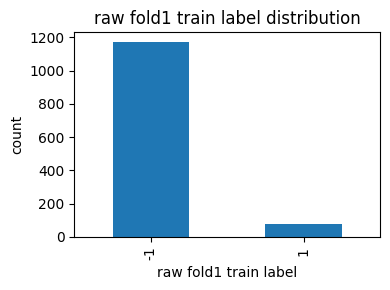


[raw fold1 train missing indicators] shape = 1,253 rows x 268 columns
- duplicated rows: 1,191
- total missing values: 0


,dtype,missing_count,missing_rate,n_unique
feature_1_M,int64,0,0.0,2
feature_2_M,int64,0,0.0,2
feature_3_M,int64,0,0.0,2
feature_4_M,int64,0,0.0,2
feature_5_M,int64,0,0.0,2
feature_7_M,int64,0,0.0,2
feature_13_M,int64,0,0.0,2
feature_15_M,int64,0,0.0,2
feature_16_M,int64,0,0.0,2
feature_17_M,int64,0,0.0,2


,feature_1_M,feature_2_M,feature_3_M,feature_4_M,feature_5_M,feature_7_M,feature_13_M,feature_15_M,feature_16_M,feature_17_M,...,feature_570_M,feature_571_M,feature_572_M,feature_573_M,feature_574_M,feature_575_M,feature_577_M,feature_578_M,feature_586_M,feature_590_M
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


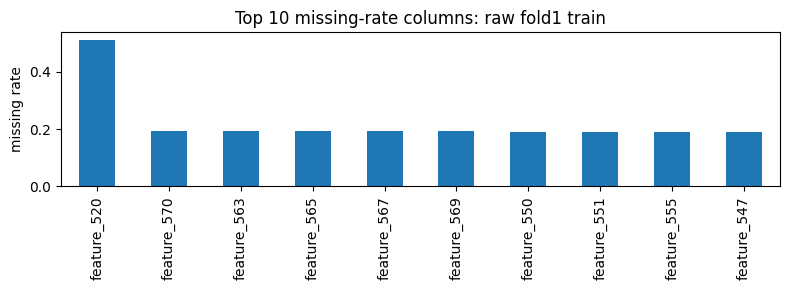

In [41]:
sample_raw_train = read_fold_file(raw_dir, 1, "train")
sample_raw_valid = read_fold_file(raw_dir, 1, "valid")

show_df_overview(sample_raw_train, "raw fold1 train")
show_df_overview(sample_raw_valid, "raw fold1 valid")
show_label_balance(sample_raw_train[LABEL_COL], "raw fold1 train label")

sample_train_m = create_missing_indicator_features(sample_raw_train, label_col=LABEL_COL)
show_df_overview(sample_train_m, "raw fold1 train missing indicators")

missing_rate_top10 = sample_raw_train.drop(columns=[LABEL_COL]).isna().mean().sort_values(ascending=False).head(10)
ax = missing_rate_top10.plot(kind="bar", figsize=(8, 3), title="Top 10 missing-rate columns: raw fold1 train")
ax.set_ylabel("missing rate")
plt.tight_layout()
plt.show()


## 4. 파이프라인별 학습/검증 데이터 구성


In [42]:
def get_base_data_by_pipeline(pipeline, fold):
    if pipeline in ["raw", "raw_M", "M_only", "mean", "mean_M"]:
        data_dir = raw_dir
    elif pipeline in ["inpaintknn", "inpaintknn_M"]:
        data_dir = inpaintknn_dir
    elif pipeline in ["mice", "mice_M"]:
        data_dir = mice_dir
    elif pipeline in ["missforest", "missforest_M"]:
        data_dir = missforest_dir
    else:
        raise ValueError(f"알 수 없는 pipeline: {pipeline}")

    train_df = read_fold_file(data_dir, fold, "train")
    valid_df = read_fold_file(data_dir, fold, "valid")

    check_label_column(train_df, f"{pipeline} fold{fold} train")
    check_label_column(valid_df, f"{pipeline} fold{fold} valid")

    train_df, valid_df = align_train_valid_columns(train_df, valid_df)

    if pipeline in ["mean", "mean_M"]:
        train_df, valid_df = mean_impute_dataframe(train_df, valid_df)

    return train_df, valid_df

def load_experiment_data(pipeline, fold):
    train_base, valid_base = get_base_data_by_pipeline(pipeline, fold)

    y_train = train_base[LABEL_COL]
    y_valid = valid_base[LABEL_COL]

    X_train_base = train_base.drop(columns=[LABEL_COL])
    X_valid_base = valid_base.drop(columns=[LABEL_COL])

    X_train_base = X_train_base[[c for c in X_train_base.columns if not str(c).endswith("_M")]]
    X_valid_base = X_valid_base[X_train_base.columns]

    train_m, valid_m = load_missing_indicator_from_original_kfold(fold)

    if pipeline == "M_only":
        X_train = train_m.copy()
        X_valid = valid_m.copy()

    elif pipeline.endswith("_M"):
        X_train = pd.concat([X_train_base, train_m], axis=1)
        X_valid = pd.concat([X_valid_base, valid_m], axis=1)
        X_train, X_valid = align_train_valid_columns(X_train, X_valid)

    else:
        X_train = X_train_base.copy()
        X_valid = X_valid_base.copy()

    return X_train, y_train, X_valid, y_valid


### Pipeline별 로드 결과 확인

각 pipeline의 Fold 1 train/valid 분포 모양 확인하고 결측치 수, 라벨 분포 비교

In [43]:
pipeline_check_rows = []

for pipeline in selected_pipelines:
    try:
        train_df, valid_df = get_base_data_by_pipeline(pipeline, 1)
        pipeline_check_rows.append({
            "pipeline": pipeline,
            "train_rows": train_df.shape[0],
            "train_cols": train_df.shape[1],
            "valid_rows": valid_df.shape[0],
            "valid_cols": valid_df.shape[1],
            "train_missing": int(train_df.isna().sum().sum()),
            "valid_missing": int(valid_df.isna().sum().sum()),
            "train_pos": int((train_df[LABEL_COL] == POSITIVE_CLASS).sum()),
            "valid_pos": int((valid_df[LABEL_COL] == POSITIVE_CLASS).sum()),
        })
    except Exception as e:
        pipeline_check_rows.append({"pipeline": pipeline, "error": str(e)[:200]})

pipeline_check_df = pd.DataFrame(pipeline_check_rows)
display(pipeline_check_df)


,pipeline,train_rows,train_cols,valid_rows,valid_cols,train_missing,valid_missing,train_pos,valid_pos
0,raw,1253,269,157,269,6076,622,81,10
1,raw_M,1253,269,157,269,6076,622,81,10
2,M_only,1253,269,157,269,6076,622,81,10
3,inpaintknn,1253,269,157,269,0,0,81,10
4,mice,1253,269,157,269,0,0,81,10
5,missforest,1253,269,157,269,0,0,81,10
6,mean,1253,269,157,269,0,0,81,10
7,mean_M,1253,269,157,269,0,0,81,10
8,inpaintknn_M,1253,269,157,269,0,0,81,10
9,mice_M,1253,269,157,269,0,0,81,10


## 5. Feature Selection 설정 및 적용


In [44]:
FEATURE_SELECTORS = {
    "raw": lambda X, y: None,
    "chi2": lambda X, y: SelectKBest(chi2, k=min(N_FEATURES_SELECT, X.shape[1])),
    "f_classif": lambda X, y: SelectKBest(f_classif, k=min(N_FEATURES_SELECT, X.shape[1])),
    "mutual_info": lambda X, y: SelectKBest(mutual_info_classif, k=min(N_FEATURES_SELECT, X.shape[1])),
    "fpr": lambda X, y: SelectFpr(alpha=0.05),
    "fdr": lambda X, y: SelectFdr(alpha=0.05),
    "fwe": lambda X, y: SelectFwe(alpha=0.05),
}

def _check_selected_cols(selected_cols, fs_key, pipeline):
    if len(selected_cols) == 0:
        raise ValueError(f"{pipeline}-{fs_key}: feature selection selected 0 features")

def apply_feature_selection(fs_key, X_train, y_train, X_valid, pipeline):
    X_train = pd.DataFrame(X_train).copy()
    X_valid = pd.DataFrame(X_valid).copy()

    if pipeline.endswith("_M"):
        m_cols = [c for c in X_train.columns if str(c).endswith("_M")]
        base_cols = [c for c in X_train.columns if not str(c).endswith("_M")]

        X_train_base = X_train[base_cols].copy()

        if fs_key == "raw":
            selected_base_cols = base_cols
            selector = None
        else:
            X_train_for_fs = X_train_base.copy()

            if fs_key == "chi2":
                X_train_for_fs = np.clip(X_train_for_fs, 0, None)

            selector = FEATURE_SELECTORS[fs_key](X_train_for_fs, y_train)
            selector.fit(X_train_for_fs, y_train)

            selected_base_cols = list(X_train_base.columns[selector.get_support()])

        _check_selected_cols(selected_base_cols, fs_key, pipeline)

        selected_m_cols = [f"{c}_M" for c in selected_base_cols if f"{c}_M" in m_cols]
        final_cols = selected_base_cols + selected_m_cols

        return X_train[final_cols], X_valid[final_cols], selector, final_cols

    if pipeline == "M_only":
        if fs_key == "raw":
            selected_cols = list(X_train.columns)
            _check_selected_cols(selected_cols, fs_key, pipeline)
            return X_train, X_valid, None, selected_cols

        X_train_for_fs = X_train.copy()

        if fs_key == "chi2":
            X_train_for_fs = np.clip(X_train_for_fs, 0, None)

        selector = FEATURE_SELECTORS[fs_key](X_train_for_fs, y_train)
        selector.fit(X_train_for_fs, y_train)

        selected_cols = list(X_train.columns[selector.get_support()])
        _check_selected_cols(selected_cols, fs_key, pipeline)

        return X_train[selected_cols], X_valid[selected_cols], selector, selected_cols

    if fs_key == "raw":
        selected_cols = list(X_train.columns)
        _check_selected_cols(selected_cols, fs_key, pipeline)
        return X_train, X_valid, None, selected_cols

    X_train_for_fs = X_train.copy()

    if fs_key == "chi2":
        X_train_for_fs = np.clip(X_train_for_fs, 0, None)

    selector = FEATURE_SELECTORS[fs_key](X_train_for_fs, y_train)
    selector.fit(X_train_for_fs, y_train)

    selected_cols = list(X_train.columns[selector.get_support()])
    _check_selected_cols(selected_cols, fs_key, pipeline)

    return X_train[selected_cols], X_valid[selected_cols], selector, selected_cols


### 피처 선택 결과 확인

Fold 1, mean pipeline 기준 피쳐 셀렉션별 선택 피처 수와 예시 컬럼 확인

mean fold1 X_train shape: (1253, 268), X_valid shape: (157, 268)


,count,ratio
mean fold1 train label,,
-1,1172,0.935355
1,81,0.064645


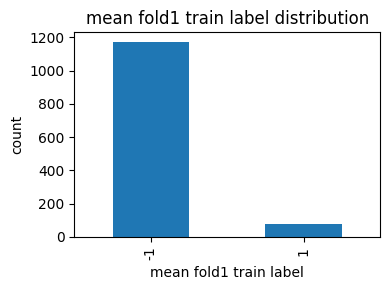

,feature_selection,n_selected,train_shape,valid_shape,example_features
0,chi2,50,"(1253, 50)","(157, 50)","feature_4, feature_5, feature_24, feature_25, ..."
1,f_classif,50,"(1253, 50)","(157, 50)","feature_22, feature_29, feature_32, feature_33..."
2,mutual_info,50,"(1253, 50)","(157, 50)","feature_3, feature_33, feature_34, feature_36,..."
3,fpr,34,"(1253, 34)","(157, 34)","feature_29, feature_34, feature_60, feature_64..."
4,fdr,7,"(1253, 7)","(157, 7)","feature_29, feature_60, feature_130, feature_5..."
5,fwe,6,"(1253, 6)","(157, 6)","feature_60, feature_130, feature_511, feature_..."
6,raw,268,"(1253, 268)","(157, 268)","feature_1, feature_2, feature_3, feature_4, fe..."


In [45]:
X_train_sample, y_train_sample, X_valid_sample, y_valid_sample = load_experiment_data("mean", 1)
print(f"mean fold1 X_train shape: {X_train_sample.shape}, X_valid shape: {X_valid_sample.shape}")
show_label_balance(y_train_sample, "mean fold1 train label")

fs_check_rows = []
for fs_key in selected_feature_selectors:
    try:
        X_train_fs, X_valid_fs, selector, selected_cols = apply_feature_selection(
            fs_key, X_train_sample, y_train_sample, X_valid_sample, "mean"
        )
        fs_check_rows.append({
            "feature_selection": fs_key,
            "n_selected": len(selected_cols),
            "train_shape": str(X_train_fs.shape),
            "valid_shape": str(X_valid_fs.shape),
            "example_features": ", ".join(map(str, selected_cols[:8])),
        })
    except Exception as e:
        fs_check_rows.append({"feature_selection": fs_key, "error": str(e)[:200]})

display(pd.DataFrame(fs_check_rows))


## 6. 모델, 불균형 처리, 스케일링


In [46]:
MODELS = {
    "knn": KNeighborsClassifier(n_neighbors=5),
    "svm": SVC(probability=True, random_state=RANDOM_STATE),
    "rf": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=MODEL_N_JOBS
    ),
    "lr": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=10000
    ),
    "hgb": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "xgboost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=MODEL_N_JOBS
    )
}


PARAM_GRIDS = {
    "knn": {
        "n_neighbors": [3, 5, 7, 11, 15],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
    },
    "svm": {
        "C": [0.1, 1, 10, 50],
        "gamma": ["scale", 0.01, 0.001],
        "class_weight": [None, "balanced"],
    },
    "rf": {
        "n_estimators": [300, 500],
        "max_depth": [None, 5, 10, 20],
        "min_samples_leaf": [1, 3, 5],
        "class_weight": [None, "balanced", "balanced_subsample"],
    },
    "lr": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"],
        "class_weight": [None, "balanced"],
    },
    "hgb": {
        "learning_rate": [0.03, 0.05, 0.1],
        "max_iter": [200, 500],
        "max_leaf_nodes": [15, 31, 63],
        "l2_regularization": [0, 0.1, 1],
    },
    "xgboost": {
        "n_estimators": [200, 500],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.7, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.9, 1.0],
        "scale_pos_weight": ["auto"],
    },
}


BALANCERS = {
    "raw": lambda X, y: (X, y),
    "smote": lambda X, y: SMOTE(random_state=RANDOM_STATE).fit_resample(X, y)
}

def scale_data(model_key, X_train, X_valid):
    if model_key in ["lr", "svm", "knn"]:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)
        return X_train_scaled, X_valid_scaled

    return X_train, X_valid


### 모델/하이퍼파라미터 후보 확인

모델별 기본 객체 & parameter 후보 개수 확인

In [47]:
model_check_rows = []

for model_key in selected_models:
    all_candidates = list(ParameterGrid(PARAM_GRIDS[model_key]))
    cap = MAX_PARAM_CANDIDATES.get(model_key)
    model_check_rows.append({
        "model": model_key,
        "estimator": type(MODELS[model_key]).__name__,
        "param_candidates_before_cap": len(all_candidates),
        "max_param_candidates": cap,
        "param_candidates_after_cap": min(len(all_candidates), cap) if cap is not None else len(all_candidates),
    })

model_check_df = pd.DataFrame(model_check_rows)
display(model_check_df)


,model,estimator,param_candidates_before_cap,max_param_candidates,param_candidates_after_cap
0,knn,KNeighborsClassifier,20,10,10
1,svm,SVC,24,12,12
2,rf,RandomForestClassifier,72,18,18
3,lr,LogisticRegression,8,8,8
4,hgb,HistGradientBoostingClassifier,54,18,18
5,xgboost,XGBClassifier,162,24,24


## 7. 평가 지표 및 학습/예측 함수


In [48]:
def get_positive_proba(model, X, positive_class=POSITIVE_CLASS):
    if not hasattr(model, "predict_proba"):
        return None

    y_proba = model.predict_proba(X)

    if y_proba.ndim == 1:
        return y_proba

    classes = list(model.classes_)

    if positive_class in classes:
        pos_idx = classes.index(positive_class)
    elif 1 in classes:
        pos_idx = classes.index(1)
    else:
        pos_idx = -1

    return y_proba[:, pos_idx]

def get_auc(y_true, y_score, positive_class=POSITIVE_CLASS):
    if y_score is None:
        return None

    y_true_array = np.asarray(y_true)

    if len(np.unique(y_true_array)) < 2:
        return None

    try:
        y_binary = (y_true_array == positive_class).astype(int)
        return roc_auc_score(y_binary, y_score)
    except Exception:
        return None

def evaluate_model(y_true, y_pred, y_score=None, positive_class=POSITIVE_CLASS):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    labels_for_cm = [-1, positive_class] if set(np.unique(y_true_array)).issubset({-1, positive_class}) else np.unique(y_true_array)

    if len(labels_for_cm) == 2:
        negative_class = labels_for_cm[0] if labels_for_cm[0] != positive_class else labels_for_cm[1]

        cm = confusion_matrix(
            y_true_array,
            y_pred_array,
            labels=[negative_class, positive_class]
        )

        tn, fp, fn, tp = cm.ravel()

        precision = precision_score(
            y_true_array,
            y_pred_array,
            pos_label=positive_class,
            zero_division=0
        )

        recall = recall_score(
            y_true_array,
            y_pred_array,
            pos_label=positive_class,
            zero_division=0
        )

        f1_binary = f1_score(
            y_true_array,
            y_pred_array,
            pos_label=positive_class,
            zero_division=0
        )

        f2_binary = fbeta_score(
            y_true_array,
            y_pred_array,
            beta=2,
            pos_label=positive_class,
            zero_division=0
        )

        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0

    else:
        cm = confusion_matrix(y_true_array, y_pred_array)
        tn = fp = fn = tp = np.nan

        precision = precision_score(
            y_true_array,
            y_pred_array,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_true_array,
            y_pred_array,
            average="weighted",
            zero_division=0
        )

        f1_binary = np.nan
        f2_binary = np.nan
        tnr = np.nan

    auc_value = get_auc(
        y_true_array,
        y_score,
        positive_class=positive_class
    )

    return {
        "f1": f1_score(y_true_array, y_pred_array, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true_array, y_pred_array, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_array, y_pred_array, average="macro", zero_division=0),
        "f1_binary": f1_binary,
        "f2": f2_binary,
        "f2_binary": f2_binary,
        "auc": auc_value,
        "tp": int(tp) if not pd.isna(tp) else np.nan,
        "tn": int(tn) if not pd.isna(tn) else np.nan,
        "fp": int(fp) if not pd.isna(fp) else np.nan,
        "fn": int(fn) if not pd.isna(fn) else np.nan,
        "precision": precision,
        "recall": recall,
        "tnr": tnr,
        "confusion_matrix": cm.tolist()
    }

def fit_predict_model(model_key, model, X_train, y_train, X_valid):
    if model_key == "xgboost":
        y_train_fit = (np.asarray(y_train) == POSITIVE_CLASS).astype(int)

        model.fit(X_train, y_train_fit)

        y_pred_binary = model.predict(X_valid)
        y_pred = np.where(y_pred_binary == 1, POSITIVE_CLASS, -1)

        y_score = get_positive_proba(model, X_valid, positive_class=1)

        return y_pred, y_score

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)
    y_score = get_positive_proba(model, X_valid, positive_class=POSITIVE_CLASS)

    return y_pred, y_score

def get_class_ratio(y, positive_class=POSITIVE_CLASS):
    y_array = np.asarray(y)
    n_pos = np.sum(y_array == positive_class)
    n_neg = len(y_array) - n_pos

    if n_pos == 0:
        return 1.0

    return float(n_neg / n_pos)


def resolve_model_params(model_key, params, y_reference, balancing_key):
    resolved = dict(params)

    if model_key == "xgboost" and resolved.get("scale_pos_weight") == "auto":
        resolved["scale_pos_weight"] = (
            1.0 if balancing_key == "smote"
            else get_class_ratio(y_reference, positive_class=POSITIVE_CLASS)
        )

    return resolved


def get_param_candidates(model_key):
    if not TUNE_HYPERPARAMETERS:
        return [{}]

    all_candidates = list(ParameterGrid(PARAM_GRIDS[model_key]))
    max_candidates = MAX_PARAM_CANDIDATES.get(model_key, len(all_candidates))

    if len(all_candidates) > max_candidates:
        rng = np.random.default_rng(RANDOM_STATE)
        selected_idx = sorted(rng.choice(len(all_candidates), size=max_candidates, replace=False))
        all_candidates = [all_candidates[i] for i in selected_idx]

    return [{}] + [p for p in all_candidates if p != {}]


def find_best_threshold_by_f2(y_true, y_score, positive_class=POSITIVE_CLASS):
    if y_score is None:
        return 0.5

    y_score = np.asarray(y_score)
    if y_score.size == 0:
        return 0.5

    thresholds = np.unique(np.concatenate(([0.0, 0.5, 1.0], y_score)))
    best_threshold = 0.5
    best_score = -1.0

    for threshold in thresholds:
        y_pred = np.where(y_score >= threshold, positive_class, -1)
        score = fbeta_score(
            y_true,
            y_pred,
            beta=2,
            pos_label=positive_class,
            zero_division=0
        )

        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    return best_threshold


def tune_model_and_threshold_from_inner_train(model_key, X_train, y_train, balancing_key):
    y_array = np.asarray(y_train)
    classes, counts = np.unique(y_array, return_counts=True)

    if len(classes) < 2 or counts.min() < 2:
        return {}, 0.5, np.nan

    try:
        X_inner_train, X_inner_valid, y_inner_train, y_inner_valid = train_test_split(
            X_train,
            y_train,
            test_size=INNER_THRESHOLD_VALID_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_train
        )
    except ValueError:
        return {}, 0.5, np.nan

    best_params = {}
    best_threshold = 0.5
    best_score = -1.0

    for candidate_params in get_param_candidates(model_key):
        try:
            resolved_params = resolve_model_params(
                model_key=model_key,
                params=candidate_params,
                y_reference=y_inner_train,
                balancing_key=balancing_key
            )

            X_inner_bal, y_inner_bal = BALANCERS[balancing_key](X_inner_train, y_inner_train)
            X_inner_bal_scaled, X_inner_valid_scaled = scale_data(
                model_key,
                X_inner_bal,
                X_inner_valid
            )

            model = clone(MODELS[model_key])
            model.set_params(**resolved_params)

            _, y_inner_score = fit_predict_model(
                model_key=model_key,
                model=model,
                X_train=X_inner_bal_scaled,
                y_train=y_inner_bal,
                X_valid=X_inner_valid_scaled
            )

            threshold = find_best_threshold_by_f2(
                y_true=y_inner_valid,
                y_score=y_inner_score,
                positive_class=POSITIVE_CLASS
            )

            y_inner_pred = np.where(y_inner_score >= threshold, POSITIVE_CLASS, -1)
            score = fbeta_score(
                y_inner_valid,
                y_inner_pred,
                beta=2,
                pos_label=POSITIVE_CLASS,
                zero_division=0
            )

            if score > best_score:
                best_score = score
                best_threshold = threshold
                best_params = resolved_params

        except Exception:
            continue

    if best_score < 0:
        return {}, 0.5, np.nan

    return best_params, best_threshold, best_score


## 8. 단일 실험 실행 함수


In [49]:
def run_experiment(pipeline, balancing_key, fs_key, model_key, fold):
    X_train, y_train, X_valid, y_valid = load_experiment_data(pipeline, fold)

    X_train_fs, X_valid_fs, selector, selected_cols = apply_feature_selection(
        fs_key, X_train, y_train, X_valid, pipeline
    )

    best_params, best_threshold, inner_f2 = tune_model_and_threshold_from_inner_train(
        model_key=model_key,
        X_train=X_train_fs,
        y_train=y_train,
        balancing_key=balancing_key
    )

    X_train_bal, y_train_bal = BALANCERS[balancing_key](X_train_fs, y_train)

    X_train_scaled, X_valid_scaled = scale_data(model_key, X_train_bal, X_valid_fs)

    model = clone(MODELS[model_key])
    model.set_params(**best_params)

    y_pred_default, y_score = fit_predict_model(
        model_key=model_key,
        model=model,
        X_train=X_train_scaled,
        y_train=y_train_bal,
        X_valid=X_valid_scaled
    )

    if y_score is not None:
        y_pred = np.where(y_score >= best_threshold, POSITIVE_CLASS, -1)
    else:
        y_pred = y_pred_default

    metrics = evaluate_model(
        y_true=y_valid,
        y_pred=y_pred,
        y_score=y_score,
        positive_class=POSITIVE_CLASS
    )

    if y_score is not None and len(np.unique(y_valid)) == 2:
        y_binary = (np.asarray(y_valid) == POSITIVE_CLASS).astype(int)
        fpr, tpr, _ = roc_curve(y_binary, y_score)

        metrics["roc_fpr"] = fpr.tolist()
        metrics["roc_tpr"] = tpr.tolist()

    n_base_features = len([c for c in selected_cols if not str(c).endswith("_M")])
    n_m_features = len([c for c in selected_cols if str(c).endswith("_M")])

    metrics.update({
        "pipeline": pipeline,
        "balancing": balancing_key,
        "feature_selection": fs_key,
        "model": model_key,
        "fold": fold,
        "best_threshold": best_threshold,
        "threshold_source": "inner_train_holdout_f2",
        "inner_f2": inner_f2,
        "model_params": str(best_params),
        "n_param_candidates": len(get_param_candidates(model_key)),
        "n_features": X_train_fs.shape[1],
        "n_base_features": n_base_features,
        "n_m_features": n_m_features,
        "selected_features": "|".join(map(str, selected_cols))
    })

    return metrics


## 9. 데이터 사전 검증 함수


In [50]:
def validate_data_availability(pipelines, folds):
    print("\n=== 데이터 검증 ===\n")

    dir_mapping = {
        "raw": raw_dir,
        "raw_M": raw_dir,
        "M_only": raw_dir,
        "mean": raw_dir,
        "mean_M": raw_dir,
        "inpaintknn": inpaintknn_dir,
        "inpaintknn_M": inpaintknn_dir,
        "mice": mice_dir,
        "mice_M": mice_dir,
        "missforest": missforest_dir,
        "missforest_M": missforest_dir,
    }

    missing_count = 0

    for pipeline in pipelines:
        data_dir = dir_mapping[pipeline]

        for fold in folds:
            for split in ["train", "valid"]:
                try:
                    _ = read_fold_file(data_dir, fold, split)
                except FileNotFoundError:
                    print(f"Er. 누락: {pipeline} fold{fold}_{split}")
                    missing_count += 1

    if missing_count == 0:
        print("수정 완료. 모든 데이터 파일 확인 완료")
    else:
        print(f"Er. {missing_count}개 파일 누락")

    return missing_count == 0

def smoke_test_file_loading(pipelines, fold=1):

    failed = []

    for pipeline in pipelines:
        try:
            train_df, valid_df = get_base_data_by_pipeline(pipeline, fold)
            print(f"수정 완료. {pipeline}: train={train_df.shape}, valid={valid_df.shape}")
        except Exception as e:
            failed.append((pipeline, str(e)))
            print(f"실패. {pipeline}: {str(e)[:200]}")

    if failed:
        print("\nEr. smoke test 실패 pipeline:")
        for pipeline, err in failed:
            print(f"  - {pipeline}: {err[:200]}")
        raise RuntimeError("파일 로드 smoke test 실패. 위 pipeline의 파일명/경로를 확인하세요.")


## 10. M 피처 효과 비교 함수


In [51]:
def get_pair_pipeline(pipeline):
    pair_map = {
        "raw_M": "raw",
        "mean_M": "mean",
        "inpaintknn_M": "inpaintknn",
        "mice_M": "mice",
        "missforest_M": "missforest",
    }
    return pair_map.get(pipeline, None)

def build_m_comparison_table(results_df):
    key_cols = ["balancing", "feature_selection", "model", "fold"]

    metrics = [
        "f1",
        "f1_binary",
        "f1_macro",
        "f2",
        "f2_binary",
        "auc",
        "precision",
        "recall",
        "tnr"
    ]

    required_cols = set(["pipeline"] + key_cols)
    if results_df is None or len(results_df) == 0 or not required_cols.issubset(results_df.columns):
        return pd.DataFrame()

    comparison_rows = []
    m_pipelines = ["raw_M", "mean_M", "inpaintknn_M", "mice_M", "missforest_M"]

    for m_pipeline in m_pipelines:
        base_pipeline = get_pair_pipeline(m_pipeline)

        m_df = results_df[results_df["pipeline"] == m_pipeline]
        base_df = results_df[results_df["pipeline"] == base_pipeline]

        merged = pd.merge(
            base_df,
            m_df,
            on=key_cols,
            suffixes=("_base", "_M")
        )

        for _, row in merged.iterrows():
            out = {
                "base_pipeline": base_pipeline,
                "M_pipeline": m_pipeline
            }

            for c in key_cols:
                out[c] = row[c]

            for metric in metrics:
                out[f"{metric}_base"] = row.get(f"{metric}_base", np.nan)
                out[f"{metric}_M"] = row.get(f"{metric}_M", np.nan)
                out[f"{metric}_gain"] = out[f"{metric}_M"] - out[f"{metric}_base"]

            comparison_rows.append(out)

    return pd.DataFrame(comparison_rows)

def aggregate_m_comparison(comparison_df):
    if len(comparison_df) == 0:
        return pd.DataFrame()

    group_cols = ["base_pipeline", "M_pipeline", "balancing", "feature_selection", "model"]
    numeric_cols = comparison_df.select_dtypes(include=[np.number]).columns.tolist()

    agg_df = comparison_df.groupby(group_cols)[numeric_cols].agg(["mean", "std"]).reset_index()
    agg_df.columns = [
        "_".join(col).strip("_") if isinstance(col, tuple) else col
        for col in agg_df.columns
    ]

    return agg_df


## 11. 시각화


In [52]:
def plot_performance_boxplots(results_df, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    metrics = ["f1", "f2", "auc", "precision", "recall", "tnr"]

    for metric in metrics:
        if metric not in results_df.columns:
            continue

        pipelines = results_df["pipeline"].dropna().unique().tolist()

        data = [
            results_df[results_df["pipeline"] == p][metric].dropna().values
            for p in pipelines
        ]

        if all(len(x) == 0 for x in data):
            continue

        plt.figure(figsize=(12, 5))
        plt.boxplot(data, labels=pipelines)
        plt.ylabel(metric)
        plt.title(f"{metric} distribution by pipeline")
        plt.xticks(rotation=70, ha="right")
        plt.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        plt.savefig(output_dir / f"boxplot_{metric}_by_pipeline.png", dpi=300, bbox_inches="tight")
        plt.close()

def plot_gain_barplots(agg_comparison_df, output_dir, top_n=20):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    gain_cols = [
        "f1_gain_mean",
        "f2_gain_mean",
        "auc_gain_mean",
        "precision_gain_mean",
        "recall_gain_mean",
        "tnr_gain_mean"
    ]

    for gain_col in gain_cols:
        if gain_col not in agg_comparison_df.columns:
            continue

        top_df = agg_comparison_df.sort_values(gain_col, ascending=False).head(top_n).copy()

        labels = (
            top_df["M_pipeline"].astype(str) + "-" +
            top_df["balancing"].astype(str) + "-" +
            top_df["feature_selection"].astype(str) + "-" +
            top_df["model"].astype(str)
        )

        plt.figure(figsize=(12, 6))
        plt.bar(range(len(top_df)), top_df[gain_col].values)
        plt.xticks(range(len(top_df)), labels, rotation=80, ha="right")
        plt.ylabel(gain_col)
        plt.title(f"Top {top_n} {gain_col}")
        plt.grid(alpha=0.3, axis="y")
        plt.tight_layout()
        plt.savefig(output_dir / f"barplot_top_{gain_col}.png", dpi=300, bbox_inches="tight")
        plt.close()

def plot_roc_curves_top_models(results_df, output_dir, top_n=5):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if "roc_fpr" not in results_df.columns or "roc_tpr" not in results_df.columns:
        return

    top_results = results_df.sort_values("f1", ascending=False).head(top_n)

    plt.figure(figsize=(7, 6))
    plotted = 0

    for _, row in top_results.iterrows():
        if isinstance(row.get("roc_fpr"), list) and isinstance(row.get("roc_tpr"), list):
            auc_text = row["auc"] if pd.notna(row["auc"]) else np.nan
            label = f"{row['pipeline']}-{row['model']}-{row['feature_selection']} AUC={auc_text:.3f}"
            plt.plot(row["roc_fpr"], row["roc_tpr"], label=label)
            plotted += 1

    if plotted == 0:
        plt.close()
        return

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves: Top Models by F1")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / "roc_curves_top_models_by_f1.png", dpi=300, bbox_inches="tight")
    plt.close()

def normalize_confusion_matrix(cm):
    if isinstance(cm, str):
        text = cm.strip()
        try:
            cm = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            values = np.fromstring(
                text.replace("[", " ").replace("]", " ").replace(",", " "),
                sep=" "
            )
            if values.size == 4:
                cm = values.reshape(2, 2)
            else:
                raise ValueError(f"Invalid confusion_matrix value: {text}")

    cm = np.asarray(cm, dtype=float)
    if cm.ndim != 2:
        raise ValueError(f"confusion_matrix must be 2D, got shape {cm.shape}")
    return cm


def plot_confusion_matrix_heatmap(cm, title, save_path):
    cm = normalize_confusion_matrix(cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Pred -1", "Pred 1"])
    plt.yticks(tick_marks, ["True -1", "True 1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(int(cm[i, j]), "d"), ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

def plot_top_confusion_matrices(results_df, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if len(results_df) == 0:
        return

    top_f1 = results_df.sort_values("f1", ascending=False).head(1)
    top_f2 = results_df.sort_values("f2", ascending=False).head(1)

    if len(top_f1) > 0:
        row = top_f1.iloc[0]
        title = (
            f"Top F1 CM\n"
            f"{row['pipeline']}-{row['balancing']}-{row['feature_selection']}-{row['model']}-fold{row['fold']}"
        )
        plot_confusion_matrix_heatmap(
            row["confusion_matrix"],
            title,
            output_dir / "confusion_matrix_top_f1.png"
        )

    if len(top_f2) > 0:
        row = top_f2.iloc[0]
        title = (
            f"Top F2 CM\n"
            f"{row['pipeline']}-{row['balancing']}-{row['feature_selection']}-{row['model']}-fold{row['fold']}"
        )
        plot_confusion_matrix_heatmap(
            row["confusion_matrix"],
            title,
            output_dir / "confusion_matrix_top_f2.png"
        )

def create_all_visualizations(results_df, agg_comparison_df, output_dir):
    plot_performance_boxplots(results_df, output_dir)

    if len(agg_comparison_df) > 0:
        plot_gain_barplots(agg_comparison_df, output_dir)

    plot_roc_curves_top_models(results_df, output_dir)
    plot_top_confusion_matrices(results_df, output_dir)

    print(f"수정 완료 + 시각화 저장 완료: {output_dir}")


## 12. Simple Baseline 추출


In [53]:
def extract_simple_baseline(results_df):
    baseline = results_df[
        (results_df["pipeline"] == "mean") &
        (results_df["balancing"] == "raw") &
        (results_df["feature_selection"] == "raw") &
        (results_df["model"] == "lr")
    ].copy()

    return baseline


## 13. 분석 실행 설정, 사전 점검

In [54]:
print("=" * 70)
print("파이프라인 분석 시작")
print("=" * 70)

print("\n[전체 파이프라인]")
print("1. Data pipeline 11가지:")
for p in selected_pipelines:
    print(f"  - {p}")

print("\n2. Balancing:")
print("  - raw")
print("  - smote")
print("  - M_only includes smote")

print("\n3. Feature selection 7가지:")
for fs in selected_feature_selectors:
    print(f"  - {fs}")

print("\n4. ML model 6가지:")
for m in selected_models:
    print(f"  - {m}")

print("\n5. Evaluation:")
print("  - F1-score")
print("  - F2-score")
print("  - hyperparameters and best_threshold selected on inner-train holdout by F2")
print("  - ROC Curve, Top F1 기준")
print("  - Confusion Matrix, Top F1 1장 + Top F2 1장")
print("  - Precision / Recall / TNR / TP / TN / FP / FN")

print(f"\n[병렬 설정 확인] N_JOBS = {N_JOBS}")
print(f"  - CPU_THREADS = {CPU_THREADS}")
print(f"  - OUTER_N_JOBS = {OUTER_N_JOBS}")
print(f"  - MODEL_N_JOBS = {MODEL_N_JOBS}")
print(f"  - BLAS_THREADS = {BLAS_THREADS}")
print(f"  - JOBLIB_TEMP_FOLDER = {os.environ.get('JOBLIB_TEMP_FOLDER')}")
print("  - Override example: SECOM_OUTER_N_JOBS=9 SECOM_MODEL_N_JOBS=4 SECOM_BLAS_THREADS=4")
print("  - 코어 이중 점유 방지 구조")

data_valid = validate_data_availability(selected_pipelines, selected_folds)

smoke_test_file_loading(selected_pipelines, fold=1)

results = []
error_details = []


파이프라인 분석 시작

[전체 파이프라인]
1. Data pipeline 11가지:
  - raw
  - raw_M
  - M_only
  - inpaintknn
  - mice
  - missforest
  - mean
  - mean_M
  - inpaintknn_M
  - mice_M
  - missforest_M

2. Balancing:
  - raw
  - smote
  - M_only includes smote

3. Feature selection 7가지:
  - chi2
  - f_classif
  - mutual_info
  - fpr
  - fdr
  - fwe
  - raw

4. ML model 6가지:
  - knn
  - svm
  - rf
  - lr
  - hgb
  - xgboost

5. Evaluation:
  - F1-score
  - F2-score
  - hyperparameters and best_threshold selected on inner-train holdout by F2
  - ROC Curve, Top F1 기준
  - Confusion Matrix, Top F1 1장 + Top F2 1장
  - Precision / Recall / TNR / TP / TN / FP / FN

[병렬 설정 확인] N_JOBS = 9
  - CPU_THREADS = 20
  - OUTER_N_JOBS = 9
  - MODEL_N_JOBS = 2
  - BLAS_THREADS = 2
  - JOBLIB_TEMP_FOLDER = /tmp/secom_joblib_tmp
  - Override example: SECOM_OUTER_N_JOBS=9 SECOM_MODEL_N_JOBS=4 SECOM_BLAS_THREADS=4
  - 코어 이중 점유 방지 구조

=== 데이터 검증 ===

수정 완료. 모든 데이터 파일 확인 완료
수정 완료. raw: train=(1253, 269), valid=(157, 269)
수정 완료. raw_M

### 실행 전 조합 수 확인

현재 설정 기준에서 전체 실험 수 + Fold별 예상 실험 수 확인

In [55]:
n_per_fold = len(selected_pipelines) * len(selected_balancers) * len(selected_feature_selectors) * len(selected_models)
n_total = n_per_fold * len(selected_folds)

plan_df = pd.DataFrame({
    "unit": ["per_fold", "total"],
    "n_experiments": [n_per_fold, n_total],
})

display(plan_df)
print(f"checkpoint_dir: {checkpoint_dir}")
print(f"checkpoint files already available: {len(list(checkpoint_dir.glob('checkpoint_fold*.xlsx')))}")


,unit,n_experiments
0,per_fold,924
1,total,8316


checkpoint_dir: /home/cksl/산공종설_0527/산공종설_0527/산업공학종합설계_FIN/checkpoint
checkpoint files already available: 65


## 14. Fold별 실험 결과 로드 & 저장


In [56]:
def run_fold_experiments(fold):
    fold_results = []
    fold_errors = []

    print(f"\n>>> Fold {fold} 시작")

    for pipeline in selected_pipelines:
        for balancing in selected_balancers:

            for fs in selected_feature_selectors:
                for model_key in selected_models:

                    try:
                        result = run_experiment(
                            pipeline=pipeline,
                            balancing_key=balancing,
                            fs_key=fs,
                            model_key=model_key,
                            fold=fold
                        )

                        fold_results.append(result)

                        print(
                            f"  {pipeline}-{balancing[:1]}-{fs[:4]}-{model_key}: "
                            f"F1={result['f1']:.4f}, "
                            f"F2={result['f2']:.4f}, "
                            f"TH={result['best_threshold']:.3f}, "
                            f"Recall={result['recall']:.4f}, "
                            f"TNR={result['tnr']:.4f}, "
                            f"AUC={str(result['auc'])[:6]}"
                        )

                        if len(fold_results) % CHECKPOINT_EVERY == 0:
                            checkpoint_df = pd.DataFrame(fold_results)
                            checkpoint_path = checkpoint_dir / f"checkpoint_fold{fold}_{len(fold_results)}.xlsx"
                            checkpoint_df.to_excel(checkpoint_path, index=False)
                            print(f"수정 완료. Checkpoint 저장 완료: {checkpoint_path.name}")

                    except Exception as e:
                        fold_errors.append((
                            pipeline, balancing, fs, model_key, fold, str(e)
                        ))

                        if len(fold_errors) <= 10:
                            print(
                                f"  SKIP {pipeline}-{balancing}-{fs}-{model_key}-fold{fold}: "
                                f"{str(e)[:120]}"
                            )

    if len(fold_results) > 0:
        checkpoint_df = pd.DataFrame(fold_results)
        checkpoint_path = checkpoint_dir / f"checkpoint_fold{fold}_final.xlsx"
        checkpoint_df.to_excel(checkpoint_path, index=False)
        print(f"수정 완료. Fold {fold} final checkpoint 저장 완료: {checkpoint_path.name}")

    return fold_results, fold_errors

results = []
error_details = []
error_count = 0
parallel_results = []

for fold in selected_folds:
    final_path = checkpoint_dir / f"checkpoint_fold{fold}_final.xlsx"

    if final_path.exists():
        fold_df = pd.read_excel(final_path)
        fold_results = fold_df.to_dict("records")
        fold_errors = []

        parallel_results.append((fold_results, fold_errors))
        print(f"수정 완료. Fold {fold}: final checkpoint 로드 완료 ({len(fold_results)}개)")
    else:
        latest_files = sorted(
            checkpoint_dir.glob(f"checkpoint_fold{fold}_*.xlsx"),
            key=lambda path: path.stat().st_mtime
        )

        if len(latest_files) > 0:
            latest_path = latest_files[-1]
            fold_df = pd.read_excel(latest_path)
            fold_results = fold_df.to_dict("records")
            fold_errors = []

            parallel_results.append((fold_results, fold_errors))
            print(f"오류: Fold {fold}: final 없음, {latest_path.name} 로드 ({len(fold_results)}개)")
        else:
            print(f"실패. Fold {fold}: checkpoint 없음, 실험을 새로 실행합니다.")
            fold_results, fold_errors = run_fold_experiments(fold)
            parallel_results.append((fold_results, fold_errors))

for fold_results, fold_errors in parallel_results:
    results.extend(fold_results)
    error_details.extend(fold_errors)

error_count = len(error_details)

print(f"  - 성공한 실험: {len(results)}개")
print(f"  - 스킵/에러 발생: {error_count}개")

if error_count > 0:
    error_df = pd.DataFrame(
        error_details,
        columns=["pipeline", "balancing", "feature_selection", "model", "fold", "error"]
    )
    error_df.to_excel(base_dir / "error_details.xlsx", index=False)
    print("  - 에러 상세 저장: error_details.xlsx")

results_df = pd.DataFrame(results)
results_df.to_excel(base_dir / "analysis_results.xlsx", index=False)
print("\n 결과 저장: analysis_results.xlsx")


수정 완료. Fold 1: final checkpoint 로드 완료 (738개)
수정 완료. Fold 2: final checkpoint 로드 완료 (738개)
수정 완료. Fold 3: final checkpoint 로드 완료 (738개)
수정 완료. Fold 4: final checkpoint 로드 완료 (738개)
수정 완료. Fold 5: final checkpoint 로드 완료 (738개)
수정 완료. Fold 6: final checkpoint 로드 완료 (738개)
수정 완료. Fold 7: final checkpoint 로드 완료 (762개)
수정 완료. Fold 8: final checkpoint 로드 완료 (738개)
수정 완료. Fold 9: final checkpoint 로드 완료 (738개)
  - 성공한 실험: 6666개
  - 스킵/에러 발생: 0개

 결과 저장: analysis_results.xlsx


### 전체 실험 결과 테이블 확인

`results_df` 크기, 컬럼, 결측 매트릭스, Fold/Pipeline별 결과 수 + 성능 분포


[results_df] shape = 6,666 rows x 31 columns
- duplicated rows: 0
- total missing values: 0


,dtype,missing_count,missing_rate,n_unique
roc_fpr,object,0,0.0,5984
best_threshold,float64,0,0.0,5759
auc,float64,0,0.0,2651
f1,float64,0,0.0,1490
f1_weighted,float64,0,0.0,1490
confusion_matrix,object,0,0.0,1490
roc_tpr,object,0,0.0,1472
selected_features,object,0,0.0,1182
f1_macro,float64,0,0.0,1164
inner_f2,float64,0,0.0,980


,f1,f1_weighted,f1_macro,f1_binary,f2,f2_binary,auc,tp,tn,fp,...,fold,best_threshold,threshold_source,inner_f2,model_params,n_param_candidates,n_features,n_base_features,n_m_features,selected_features
0,0.872459,0.872459,0.617036,0.324324,0.447761,0.447761,0.775510,6,126,21,...,1,0.113297,inner_train_holdout_f2,0.495868,"{'class_weight': None, 'max_depth': None, 'min...",19,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
1,0.863976,0.863976,0.604755,0.307692,0.434783,0.434783,0.736054,6,124,23,...,1,0.000750,inner_train_holdout_f2,0.425532,"{'l2_regularization': 0.1, 'learning_rate': 0....",19,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
2,0.858080,0.858080,0.580854,0.263158,0.367647,0.367647,0.757143,5,124,23,...,1,0.036155,inner_train_holdout_f2,0.429688,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",25,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
3,0.827231,0.827231,0.528448,0.186047,0.273973,0.273973,0.723810,4,118,29,...,1,0.134144,inner_train_holdout_f2,0.476190,"{'class_weight': 'balanced_subsample', 'max_de...",19,536,268,268,feature_1|feature_2|feature_3|feature_4|featur...
4,0.863976,0.863976,0.604755,0.307692,0.434783,0.434783,0.736054,6,124,23,...,1,0.000750,inner_train_holdout_f2,0.425532,"{'l2_regularization': 0.1, 'learning_rate': 0....",19,536,268,268,feature_1|feature_2|feature_3|feature_4|featur...


pipeline,M_only,inpaintknn,inpaintknn_M,mean,mean_M,mice,mice_M,missforest,missforest_M,raw,raw_M
fold,,,,,,,,,,,
1,60,84,84,84,84,84,84,84,84,3,3
2,60,84,84,84,84,84,84,84,84,3,3
3,60,84,84,84,84,84,84,84,84,3,3
4,60,84,84,84,84,84,84,84,84,3,3
5,60,84,84,84,84,84,84,84,84,3,3
6,60,84,84,84,84,84,84,84,84,3,3
7,84,84,84,84,84,84,84,84,84,3,3
8,60,84,84,84,84,84,84,84,84,3,3
9,60,84,84,84,84,84,84,84,84,3,3


,missing_count,missing_rate
f1,0,0.0
f2,0,0.0
auc,0,0.0
precision,0,0.0
recall,0,0.0
tnr,0,0.0


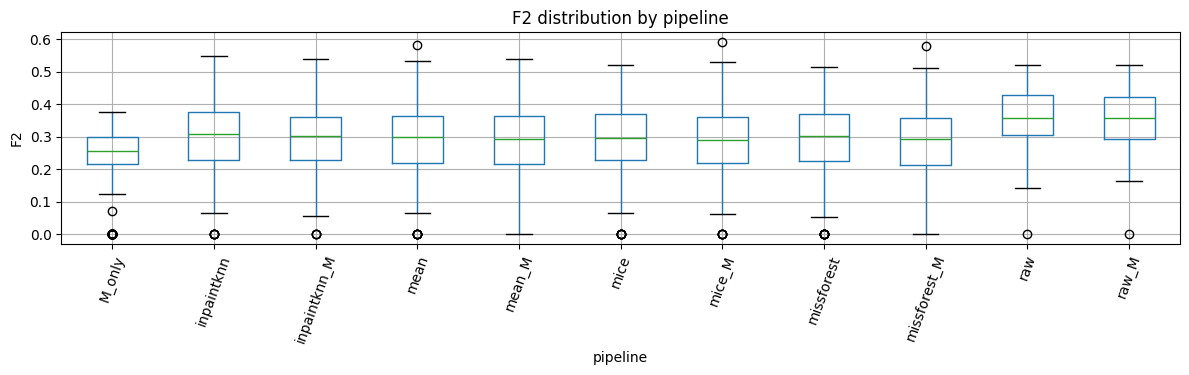

In [57]:
show_df_overview(results_df, "results_df")

if len(results_df) > 0:
    count_by_fold_pipeline = pd.crosstab(results_df["fold"], results_df["pipeline"])
    display(count_by_fold_pipeline)

    metric_cols_for_check = [c for c in ["f1", "f2", "auc", "precision", "recall", "tnr"] if c in results_df.columns]
    metric_missing_df = results_df[metric_cols_for_check].isna().sum().to_frame("missing_count")
    metric_missing_df["missing_rate"] = results_df[metric_cols_for_check].isna().mean()
    display(metric_missing_df)

    ax = results_df.boxplot(column="f2", by="pipeline", figsize=(12, 4), rot=70)
    ax.set_title("F2 distribution by pipeline")
    ax.set_xlabel("pipeline")
    ax.set_ylabel("F2")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()


## 15. 전체 실험 결과 요약


In [58]:
summary_cols = [
    "f1",
    "f1_binary",
    "f1_macro",
    "f2",
    "f2_binary",
    "auc",
    "precision",
    "recall",
    "tnr"
]

print("\n" + "=" * 70)
print("단계 4: 분석 결과 요약")
print("=" * 70)

if len(results_df) > 0:
    summary = results_df.groupby(
        ["pipeline", "balancing", "feature_selection", "model"]
    )[summary_cols].agg(["mean", "std"]).reset_index()

    summary.columns = [
        "_".join([str(x) for x in col if str(x) != ""])
        if isinstance(col, tuple) else str(col)
        for col in summary.columns
    ]

    summary.to_excel(base_dir / "summary_by_pipeline.xlsx", index=False)
    print("\n요약 결과 저장: summary_by_pipeline.xlsx")

    print("\n[상위 15개: F2 기준]")
    print(
        results_df.groupby(["pipeline", "balancing", "feature_selection", "model"])
        .agg(
            f1_mean=("f1", "mean"),
            f2_mean=("f2", "mean"),
            recall_mean=("recall", "mean"),
            tnr_mean=("tnr", "mean"),
            auc_mean=("auc", "mean"),
            count=("fold", "count")
        )
        .reset_index()
        .sort_values("f2_mean", ascending=False)
        .head(15)
        .to_string(index=False)
    )



단계 4: 분석 결과 요약

요약 결과 저장: summary_by_pipeline.xlsx

[상위 15개: F2 기준]
    pipeline balancing feature_selection   model  f1_mean  f2_mean  recall_mean  tnr_mean  auc_mean  count
inpaintknn_M       raw               raw      rf 0.810129 0.389119     0.626263  0.760403  0.737685      9
  inpaintknn     smote               raw xgboost 0.768462 0.379960     0.693939  0.693815  0.749458      9
inpaintknn_M       raw       mutual_info      rf 0.791490 0.376588     0.637374  0.731551  0.719892      9
        mice       raw       mutual_info      rf 0.802155 0.366767     0.603030  0.751323  0.714291      9
inpaintknn_M     smote         f_classif      rf 0.787816 0.362632     0.646465  0.728005  0.745912      9
      mean_M     smote               fpr      rf 0.821433 0.362368     0.559596  0.780925  0.739135      9
      mice_M       raw               raw      rf 0.819707 0.362106     0.570707  0.779409  0.742001      9
         raw       raw               raw xgboost 0.763697 0.360973     0.62

###  summary 테이블 확인

저장된 `summary`의 크기, F2 상위 조합 보고 표/그래프로 표시하기

summary shape: (762, 22)


,pipeline,balancing,feature_selection,model,f1_mean,f1_std,f1_binary_mean,f1_binary_std,f1_macro_mean,f1_macro_std,...,f2_binary_mean,f2_binary_std,auc_mean,auc_std,precision_mean,precision_std,recall_mean,recall_std,tnr_mean,tnr_std
0,M_only,raw,chi2,hgb,0.663509,0.068193,0.137132,0.055883,0.418469,0.026805,...,0.252855,0.101870,0.574036,0.072838,0.077832,0.031977,0.581818,0.234080,0.560174,0.111812
1,M_only,raw,chi2,knn,0.554367,0.208207,0.145035,0.024207,0.363851,0.117339,...,0.273608,0.038704,0.569928,0.068192,0.081454,0.014852,0.692929,0.143003,0.444853,0.172672
2,M_only,raw,chi2,lr,0.648163,0.068573,0.133177,0.054503,0.408424,0.028326,...,0.247435,0.100042,0.575847,0.069173,0.075292,0.031068,0.581818,0.234080,0.540490,0.108023
3,M_only,raw,chi2,rf,0.645350,0.065542,0.131866,0.053221,0.406311,0.023265,...,0.245743,0.098586,0.569432,0.073976,0.074426,0.030172,0.581818,0.234080,0.536711,0.105496
4,M_only,raw,chi2,svm,0.773571,0.302238,0.029365,0.058273,0.426791,0.138906,...,0.058181,0.115601,0.507919,0.065709,0.016118,0.032007,0.177778,0.366667,0.832572,0.354367
5,M_only,raw,chi2,xgboost,0.663509,0.068193,0.137132,0.055883,0.418469,0.026805,...,0.252855,0.101870,0.574200,0.073432,0.077832,0.031977,0.581818,0.234080,0.560174,0.111812
6,M_only,raw,f_classif,hgb,0.663509,0.068193,0.137132,0.055883,0.418469,0.026805,...,0.252855,0.101870,0.579668,0.073360,0.077832,0.031977,0.581818,0.234080,0.560174,0.111812
7,M_only,raw,f_classif,knn,0.488779,0.275000,0.144085,0.025066,0.328369,0.154413,...,0.274853,0.037799,0.570384,0.067998,0.080544,0.015710,0.737374,0.170102,0.392342,0.226615
8,M_only,raw,f_classif,lr,0.648163,0.068573,0.133177,0.054503,0.408424,0.028326,...,0.247435,0.100042,0.581479,0.069558,0.075292,0.031068,0.581818,0.234080,0.540490,0.108023
9,M_only,raw,f_classif,rf,0.645350,0.065542,0.131866,0.053221,0.406311,0.023265,...,0.245743,0.098586,0.575063,0.074881,0.074426,0.030172,0.581818,0.234080,0.536711,0.105496


,pipeline,balancing,feature_selection,model,f1_mean,f2_mean,recall_mean,tnr_mean
207,inpaintknn_M,raw,raw,rf,0.810129,0.389119,0.626263,0.760403
167,inpaintknn,smote,raw,xgboost,0.768462,0.379960,0.693939,0.693815
201,inpaintknn_M,raw,mutual_info,rf,0.791490,0.376588,0.637374,0.731551
453,mice,raw,mutual_info,rf,0.802155,0.366767,0.603030,0.751323
219,inpaintknn_M,smote,f_classif,rf,0.787816,0.362632,0.646465,0.728005
399,mean_M,smote,fpr,rf,0.821433,0.362368,0.559596,0.780925
543,mice_M,raw,raw,rf,0.819707,0.362106,0.570707,0.779409
758,raw,raw,raw,xgboost,0.763697,0.360973,0.626263,0.698946
397,mean_M,smote,fpr,knn,0.765987,0.360458,0.645455,0.695229
735,missforest_M,smote,fpr,rf,0.809944,0.360348,0.580808,0.761180


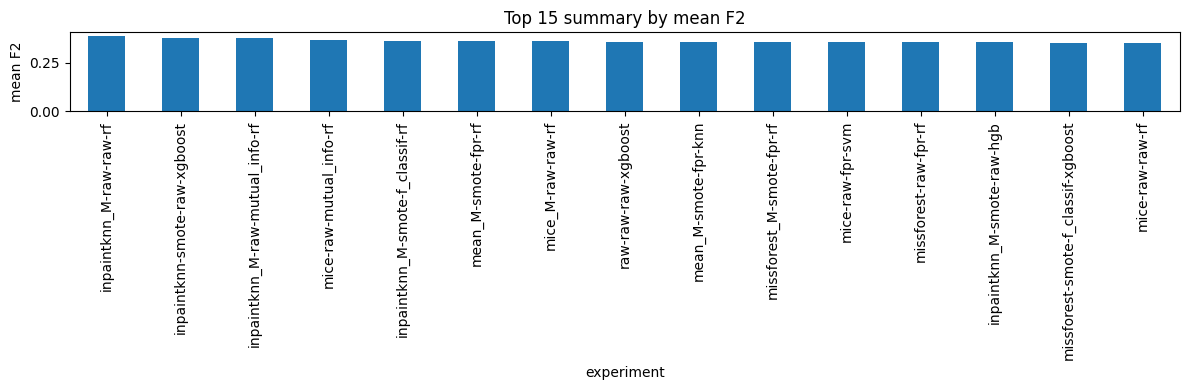

In [59]:
if "summary" in globals() and len(summary) > 0:
    print(f"summary shape: {summary.shape}")
    display(summary.head(10))

    top_summary = summary.sort_values("f2_mean", ascending=False).head(15).copy()
    display(top_summary[["pipeline", "balancing", "feature_selection", "model", "f1_mean", "f2_mean", "recall_mean", "tnr_mean"]])

    labels = (
        top_summary["pipeline"].astype(str) + "-" +
        top_summary["balancing"].astype(str) + "-" +
        top_summary["feature_selection"].astype(str) + "-" +
        top_summary["model"].astype(str)
    )
    ax = top_summary.set_index(labels)["f2_mean"].plot(kind="bar", figsize=(12, 4), title="Top 15 summary by mean F2")
    ax.set_xlabel("experiment")
    ax.set_ylabel("mean F2")
    plt.tight_layout()
    plt.show()
else:
    print("summary가 비어 있거나 생성되지 않음")


## 16. M 피처 비교 결과


In [60]:
if len(results_df) > 0 and "pipeline" in results_df.columns:
    comparison_df = build_m_comparison_table(results_df)
    comparison_df.to_excel(base_dir / "m_feature_comparison_by_fold.xlsx", index=False)
    print("\n Fold별 M 피처 비교 결과 저장: m_feature_comparison_by_fold.xlsx")

    agg_comparison_df = aggregate_m_comparison(comparison_df)

    if len(agg_comparison_df) > 0:
        agg_comparison_df.to_excel(base_dir / "m_feature_comparison_summary.xlsx", index=False)
        print("수정 완료. 평균 M 피처 비교 결과 저장: m_feature_comparison_summary.xlsx")

        print("\n[M 효과 상위 20개: F2 gain 기준]")
        show_cols = [
            "base_pipeline", "M_pipeline", "balancing", "feature_selection", "model",
            "f1_base_mean", "f1_M_mean", "f1_gain_mean",
            "f2_base_mean", "f2_M_mean", "f2_gain_mean",
            "recall_base_mean", "recall_M_mean", "recall_gain_mean",
            "tnr_base_mean", "tnr_M_mean", "tnr_gain_mean"
        ]

        available_show_cols = [c for c in show_cols if c in agg_comparison_df.columns]

        print(
            agg_comparison_df.sort_values("f2_gain_mean", ascending=False)
            .head(20)[available_show_cols]
            .to_string(index=False)
        )
    else:
        print("M 비교 가능한 결과 없음")

else:
    comparison_df = pd.DataFrame()
    agg_comparison_df = pd.DataFrame()



 Fold별 M 피처 비교 결과 저장: m_feature_comparison_by_fold.xlsx
수정 완료. 평균 M 피처 비교 결과 저장: m_feature_comparison_summary.xlsx

[M 효과 상위 20개: F2 gain 기준]
base_pipeline   M_pipeline balancing feature_selection model  f1_base_mean  f1_M_mean  f1_gain_mean  f2_base_mean  f2_M_mean  f2_gain_mean  recall_base_mean  recall_M_mean  recall_gain_mean  tnr_base_mean  tnr_M_mean  tnr_gain_mean
         mice       mice_M       raw       mutual_info   knn      0.787978   0.785993     -0.001984      0.238876   0.317048      0.078173          0.386869       0.535354          0.148485       0.749682    0.734585      -0.015096
         mice       mice_M       raw       mutual_info   hgb      0.699182   0.741748      0.042567      0.252624   0.324304      0.071679          0.493939       0.581818          0.087879       0.635164    0.675856       0.040692
         mean       mean_M     smote              chi2   svm      0.793982   0.774626     -0.019356      0.227533   0.297934      0.070401          0.361616     

### M 피처 비교 결과 확인

M indicator 추가 전후 성능 차이 보기 >> 표 + 그래프

comparison_df shape: (3051, 33)
agg_comparison_df shape: (339, 61)


,base_pipeline,M_pipeline,balancing,feature_selection,model,fold,f1_base,f1_M,f1_gain,f1_binary_base,...,auc_gain,precision_base,precision_M,precision_gain,recall_base,recall_M,recall_gain,tnr_base,tnr_M,tnr_gain
0,raw,raw_M,raw,raw,rf,1,0.872459,0.827231,-0.045228,0.324324,...,-0.051701,0.222222,0.121212,-0.101010,0.6,0.4,-0.2,0.857143,0.802721,-0.054422
1,raw,raw_M,raw,raw,hgb,1,0.863976,0.863976,0.000000,0.307692,...,0.000000,0.206897,0.206897,0.000000,0.6,0.6,0.0,0.843537,0.843537,0.000000
2,raw,raw_M,raw,raw,xgboost,1,0.858080,0.890169,0.032089,0.263158,...,-0.046939,0.178571,0.166667,-0.011905,0.5,0.2,-0.3,0.843537,0.931973,0.088435
3,raw,raw_M,raw,raw,rf,2,0.809775,0.809340,-0.000435,0.310345,...,-0.024490,0.187500,0.173913,-0.013587,0.9,0.8,-0.1,0.734694,0.741497,0.006803
4,raw,raw_M,raw,raw,hgb,2,0.889028,0.889028,0.000000,0.285714,...,0.000000,0.222222,0.222222,0.000000,0.4,0.4,0.0,0.904762,0.904762,0.000000
5,raw,raw_M,raw,raw,xgboost,2,0.851235,0.808772,-0.042463,0.285714,...,0.002041,0.187500,0.159091,-0.028409,0.6,0.7,0.1,0.823129,0.748299,-0.074830
6,raw,raw_M,raw,raw,rf,3,0.859733,0.843893,-0.015840,0.300000,...,0.037415,0.200000,0.194444,-0.005556,0.6,0.7,0.1,0.836735,0.802721,-0.034014
7,raw,raw_M,raw,raw,hgb,3,0.800264,0.800264,0.000000,0.275862,...,0.000000,0.166667,0.166667,0.000000,0.8,0.8,0.0,0.727891,0.727891,0.000000
8,raw,raw_M,raw,raw,xgboost,3,0.786189,0.659328,-0.126861,0.237288,...,0.035374,0.142857,0.115385,-0.027473,0.7,0.9,0.2,0.714286,0.530612,-0.183673
9,raw,raw_M,raw,raw,rf,4,0.678076,0.853900,0.175823,0.172840,...,0.029252,0.098592,0.172414,0.073822,0.7,0.5,-0.2,0.564626,0.836735,0.272109


,base_pipeline,M_pipeline,balancing,feature_selection,model,fold_mean,fold_std,f1_base_mean,f1_base_std,f1_M_mean,...,recall_M_mean,recall_M_std,recall_gain_mean,recall_gain_std,tnr_base_mean,tnr_base_std,tnr_M_mean,tnr_M_std,tnr_gain_mean,tnr_gain_std
0,inpaintknn,inpaintknn_M,raw,chi2,hgb,5.0,2.738613,0.836821,0.061392,0.817764,...,0.506061,0.203634,0.054545,0.123231,0.820328,0.108792,0.783897,0.101664,-0.036431,0.066511
1,inpaintknn,inpaintknn_M,raw,chi2,knn,5.0,2.738613,0.764128,0.078755,0.782446,...,0.508081,0.187438,-0.030303,0.219692,0.700530,0.118221,0.730889,0.120140,0.030359,0.085292
2,inpaintknn,inpaintknn_M,raw,chi2,lr,5.0,2.738613,0.814570,0.065414,0.770426,...,0.514141,0.199954,0.064646,0.164106,0.783856,0.107486,0.713483,0.125906,-0.070372,0.082903
3,inpaintknn,inpaintknn_M,raw,chi2,rf,5.0,2.738613,0.802273,0.048295,0.798984,...,0.526263,0.150992,0.020202,0.136650,0.758307,0.085105,0.749086,0.046093,-0.009220,0.081440
4,inpaintknn,inpaintknn_M,raw,chi2,svm,5.0,2.738613,0.799864,0.061150,0.771294,...,0.427273,0.181818,0.001010,0.157423,0.763427,0.107782,0.719344,0.112763,-0.044083,0.071340
5,inpaintknn,inpaintknn_M,raw,chi2,xgboost,5.0,2.738613,0.779241,0.042437,0.763355,...,0.592929,0.127902,0.043434,0.112520,0.718743,0.074479,0.695332,0.119227,-0.023411,0.089070
6,inpaintknn,inpaintknn_M,raw,f_classif,hgb,5.0,2.738613,0.813036,0.052147,0.808112,...,0.462626,0.195584,-0.011111,0.105409,0.777079,0.084298,0.772673,0.101650,-0.004406,0.055204
7,inpaintknn,inpaintknn_M,raw,f_classif,knn,5.0,2.738613,0.795894,0.082771,0.718297,...,0.511111,0.275882,-0.016162,0.230288,0.749174,0.128477,0.685061,0.275446,-0.064113,0.245094
8,inpaintknn,inpaintknn_M,raw,f_classif,lr,5.0,2.738613,0.831780,0.041668,0.804098,...,0.478788,0.207155,0.091919,0.287855,0.816596,0.080384,0.768625,0.136102,-0.047971,0.145431
9,inpaintknn,inpaintknn_M,raw,f_classif,rf,5.0,2.738613,0.805163,0.047970,0.814415,...,0.528283,0.102997,-0.032323,0.157663,0.756681,0.071112,0.772616,0.039256,0.015935,0.062225


,base_pipeline,M_pipeline,balancing,feature_selection,model,fold_mean,fold_std,f1_base_mean,f1_base_std,f1_M_mean,...,recall_M_mean,recall_M_std,recall_gain_mean,recall_gain_std,tnr_base_mean,tnr_base_std,tnr_M_mean,tnr_M_std,tnr_gain_mean,tnr_gain_std
199,mice,mice_M,raw,mutual_info,knn,5.0,2.738613,0.787978,0.078381,0.785993,...,0.535354,0.203098,0.148485,0.290803,0.749682,0.129178,0.734585,0.128126,-0.015096,0.175315
198,mice,mice_M,raw,mutual_info,hgb,5.0,2.738613,0.699182,0.180575,0.741748,...,0.581818,0.140689,0.087879,0.145241,0.635164,0.224493,0.675856,0.188490,0.040692,0.214291
130,mean,mean_M,smote,chi2,svm,5.0,2.738613,0.793982,0.048775,0.774626,...,0.504040,0.116430,0.142424,0.141640,0.756603,0.075570,0.715601,0.090151,-0.041003,0.081149
33,inpaintknn,inpaintknn_M,raw,mutual_info,rf,5.0,2.738613,0.768310,0.077336,0.791490,...,0.637374,0.131696,0.075758,0.106891,0.705086,0.115290,0.731551,0.098121,0.026465,0.100416
188,mice,mice_M,raw,fpr,lr,5.0,2.738613,0.784013,0.101930,0.782044,...,0.568687,0.208800,0.088889,0.169148,0.741538,0.158525,0.728631,0.146369,-0.012907,0.078862
30,inpaintknn,inpaintknn_M,raw,mutual_info,hgb,5.0,2.738613,0.752509,0.126191,0.764833,...,0.558586,0.177046,0.074747,0.270207,0.698128,0.181558,0.710035,0.181668,0.011907,0.138856
145,mean,mean_M,smote,fpr,knn,5.0,2.738613,0.796711,0.057030,0.765987,...,0.645455,0.195877,0.150505,0.177745,0.749961,0.089934,0.695229,0.118268,-0.054732,0.146960
297,missforest,missforest_M,smote,chi2,rf,5.0,2.738613,0.815615,0.057856,0.828912,...,0.465657,0.189321,0.055556,0.123603,0.790063,0.103265,0.804419,0.081022,0.014356,0.088272
21,inpaintknn,inpaintknn_M,raw,fpr,rf,5.0,2.738613,0.817962,0.030755,0.803724,...,0.574747,0.221181,0.100000,0.141421,0.784037,0.054768,0.755299,0.093073,-0.028738,0.063794
177,mice,mice_M,raw,f_classif,rf,5.0,2.738613,0.825311,0.038268,0.798706,...,0.539394,0.136060,0.110101,0.116814,0.799946,0.062641,0.749164,0.085276,-0.050782,0.060513


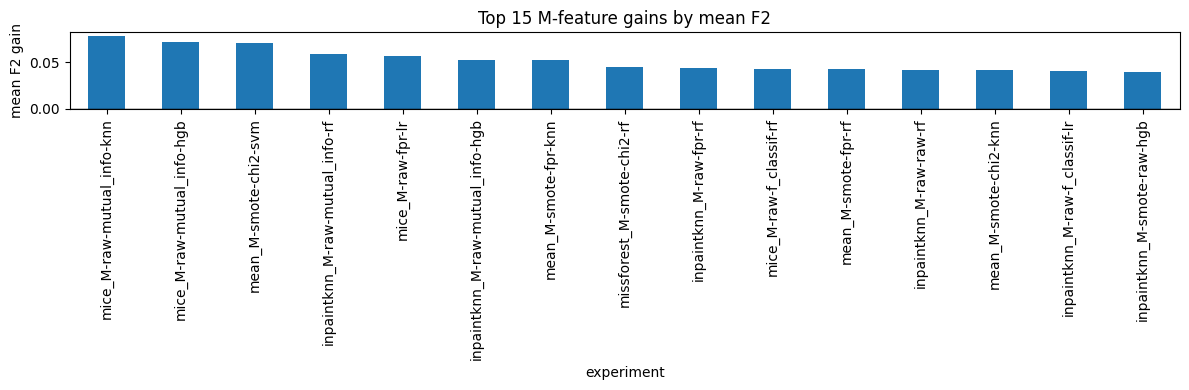

In [61]:
print(f"comparison_df shape: {comparison_df.shape}")
print(f"agg_comparison_df shape: {agg_comparison_df.shape}")

display(comparison_df.head(10))
display(agg_comparison_df.head(10))

if len(agg_comparison_df) > 0 and "f2_gain_mean" in agg_comparison_df.columns:
    top_gain = agg_comparison_df.sort_values("f2_gain_mean", ascending=False).head(15).copy()
    display(top_gain)

    labels = (
        top_gain["M_pipeline"].astype(str) + "-" +
        top_gain["balancing"].astype(str) + "-" +
        top_gain["feature_selection"].astype(str) + "-" +
        top_gain["model"].astype(str)
    )
    ax = top_gain.set_index(labels)["f2_gain_mean"].plot(kind="bar", figsize=(12, 4), title="Top 15 M-feature gains by mean F2")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel("experiment")
    ax.set_ylabel("mean F2 gain")
    plt.tight_layout()
    plt.show()


## 17. Simple Baseline 결과 요약


In [62]:
baseline_df = extract_simple_baseline(results_df)
baseline_df.to_excel(base_dir / "simple_baseline_mean_lr_raw.xlsx", index=False)

print("\n[Simple baseline: mean + LR + raw balancing + raw FS]")

if len(baseline_df) > 0:
    print(
        baseline_df[[
            "fold",
            "f1",
            "f1_binary",
            "f2",
            "best_threshold",
            "auc",
            "precision",
            "recall",
            "tnr",
            "tp",
            "tn",
            "fp",
            "fn"
        ]]
        .to_string(index=False)
    )

    print("\nSimple baseline 평균:")
    print(
        baseline_df[[
            "f1",
            "f1_binary",
            "f2",
            "auc",
            "precision",
            "recall",
            "tnr"
        ]]
        .mean()
        .to_string()
    )
else:
    print("Simple baseline 결과 없음")

print("수정 완료. Simple baseline 저장: simple_baseline_mean_lr_raw.xlsx")



[Simple baseline: mean + LR + raw balancing + raw FS]
 fold       f1  f1_binary       f2  best_threshold      auc  precision   recall      tnr  tp  tn  fp  fn
    1 0.822067   0.274510 0.432099        0.086096 0.738095   0.170732 0.700000 0.768707   7 113  34   3
    2 0.842707   0.272727 0.405405        0.517375 0.771429   0.176471 0.600000 0.809524   6 119  28   4
    3 0.579604   0.105263 0.200000        0.102650 0.537415   0.058824 0.500000 0.455782   5  67  80   5
    4 0.739225   0.179104 0.309278        0.063578 0.617007   0.105263 0.600000 0.653061   6  96  51   4
    5 0.753494   0.212121 0.364583        0.073031 0.742177   0.125000 0.700000 0.666667   7  98  49   3
    6 0.768626   0.225806 0.368421        0.068966 0.715442   0.137255 0.636364 0.698630   7 102  44   4
    7 0.777712   0.115385 0.182927        0.412864 0.539726   0.071429 0.300000 0.732877   3 107  39   7
    8 0.769574   0.142857 0.232558        0.410659 0.522603   0.086957 0.400000 0.712329   4 104  42   6


### Simple Baseline 확인

Fold별 baseline metric + 평균 성능 확인하기

baseline_df shape: (9, 31)


,f1,f1_weighted,f1_macro,f1_binary,f2,f2_binary,auc,tp,tn,fp,...,fold,best_threshold,threshold_source,inner_f2,model_params,n_param_candidates,n_features,n_base_features,n_m_features,selected_features
357,0.822067,0.822067,0.566913,0.274510,0.432099,0.432099,0.738095,7,113,34,...,1,0.086096,inner_train_holdout_f2,0.436242,"{'C': 0.01, 'class_weight': None, 'penalty': '...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
1095,0.842707,0.842707,0.577104,0.272727,0.405405,0.405405,0.771429,6,119,28,...,2,0.517375,inner_train_holdout_f2,0.426357,"{'C': 0.01, 'class_weight': 'balanced', 'penal...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
1833,0.579604,0.579604,0.358568,0.105263,0.200000,0.200000,0.537415,5,67,80,...,3,0.102650,inner_train_holdout_f2,0.382883,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
2571,0.739225,0.739225,0.478216,0.179104,0.309278,0.309278,0.617007,6,96,51,...,4,0.063578,inner_train_holdout_f2,0.372340,"{'C': 0.01, 'class_weight': None, 'penalty': '...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
3309,0.753494,0.753494,0.501222,0.212121,0.364583,0.364583,0.742177,7,98,49,...,5,0.073031,inner_train_holdout_f2,0.481928,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
4047,0.768626,0.768626,0.517665,0.225806,0.368421,0.368421,0.715442,7,102,44,...,6,0.068966,inner_train_holdout_f2,0.321637,"{'C': 0.01, 'class_weight': None, 'penalty': '...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
4809,0.777712,0.777712,0.469231,0.115385,0.182927,0.182927,0.539726,3,107,39,...,7,0.412864,inner_train_holdout_f2,0.469613,"{'C': 0.01, 'class_weight': 'balanced', 'penal...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
5547,0.769574,0.769574,0.477679,0.142857,0.232558,0.232558,0.522603,4,104,42,...,8,0.410659,inner_train_holdout_f2,0.411765,"{'C': 0.01, 'class_weight': 'balanced', 'penal...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...
6285,0.822485,0.822485,0.487179,0.102564,0.144928,0.144928,0.591781,2,119,27,...,9,0.460680,inner_train_holdout_f2,0.465839,"{'C': 0.01, 'class_weight': 'balanced', 'penal...",9,268,268,0,feature_1|feature_2|feature_3|feature_4|featur...


,count,mean,std,min,25%,50%,75%,max
f1,9.0,0.763944,0.077422,0.579604,0.753494,0.769574,0.822067,0.842707
f2,9.0,0.293355,0.105714,0.144928,0.200000,0.309278,0.368421,0.432099
auc,9.0,0.641742,0.100134,0.522603,0.539726,0.617007,0.738095,0.771429
precision,9.0,0.111210,0.043882,0.058824,0.071429,0.105263,0.137255,0.176471
recall,9.0,0.515152,0.179070,0.200000,0.400000,0.600000,0.636364,0.700000
tnr,9.0,0.701405,0.108473,0.455782,0.666667,0.712329,0.768707,0.815068


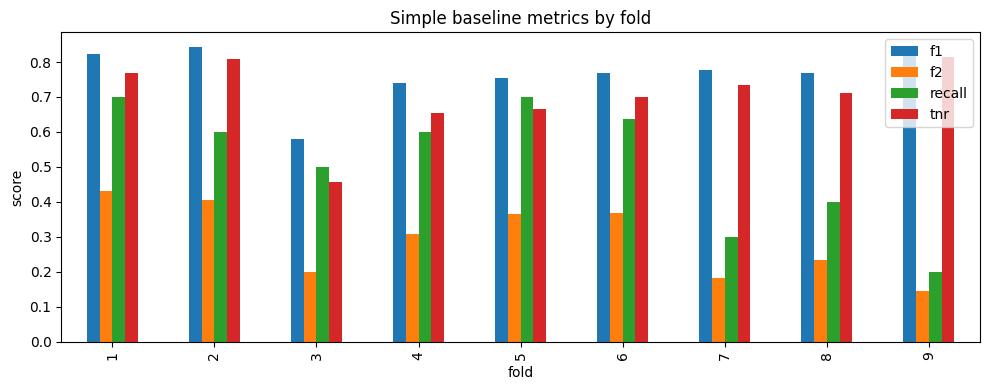

In [ ]:
print(f"baseline_df shape: {baseline_df.shape}")
display(baseline_df)

if len(baseline_df) > 0:
    baseline_metric_cols = ["f1", "f2", "auc", "precision", "recall", "tnr"]
    display(baseline_df[baseline_metric_cols].describe().T)

    ax = baseline_df.set_index("fold")[["f1", "f2", "recall", "tnr"]].plot(kind="bar", figsize=(10, 4), title="Simple baseline metrics by fold")
    ax.set_xlabel("fold")
    ax.set_ylabel("score")
    plt.tight_layout()
    plt.show()


## 18. 전체 통계 요약


In [64]:
print("\n[전체 통계 요약]")
print(f"총 성공 실험 수: {len(results_df)}개")

if len(results_df) > 0:
    print(
        f"AUC 계산 가능: "
        f"{(~results_df['auc'].isna()).sum()}개 "
        f"({100 * (~results_df['auc'].isna()).sum() / len(results_df):.1f}%)"
    )

    metric_cols = ["f1", "f1_binary", "f2", "auc", "precision", "recall", "tnr"]

    pipeline_summary = results_df.groupby("pipeline")[metric_cols].agg(["mean", "std"])
    print("\nPipeline별 성능:")
    print(pipeline_summary.to_string())

    balancing_summary = results_df.groupby("balancing")[metric_cols].agg(["mean", "std"])
    print("\nBalancing별 성능:")
    print(balancing_summary.to_string())

    model_summary = results_df.groupby("model")[metric_cols].agg(["mean", "std"])
    print("\nModel별 성능:")
    print(model_summary.to_string())



[전체 통계 요약]
총 성공 실험 수: 6666개
AUC 계산 가능: 6666개 (100.0%)

Pipeline별 성능:
                    f1           f1_binary                  f2                 auc           precision              recall                 tnr          
                  mean       std      mean       std      mean       std      mean       std      mean       std      mean       std      mean       std
pipeline                                                                                                                                                
M_only        0.556189  0.256253  0.128325  0.048932  0.241684  0.089169  0.560452  0.071826  0.072262  0.028295  0.627257  0.270164  0.476062  0.257242
inpaintknn    0.780314  0.093612  0.193033  0.068011  0.298467  0.100887  0.681610  0.095818  0.124502  0.049692  0.507912  0.211378  0.731505  0.134658
inpaintknn_M  0.766805  0.105974  0.188337  0.066419  0.294598  0.095926  0.674438  0.097608  0.121037  0.052114  0.516089  0.210643  0.712705  0.145767
mean        

## 19. 결과 시각화 생성


In [65]:
viz_dir = base_dir / "visualizations"

if len(results_df) > 0:
    create_all_visualizations(results_df, agg_comparison_df, viz_dir)
else:
    print("시각화할 결과 없음")


수정 완료 + 시각화 저장 완료: /home/cksl/산공종설_0527/산공종설_0527/산업공학종합설계_FIN/visualizations


### 시각화 미리보기

boxplot_f2_by_pipeline.png


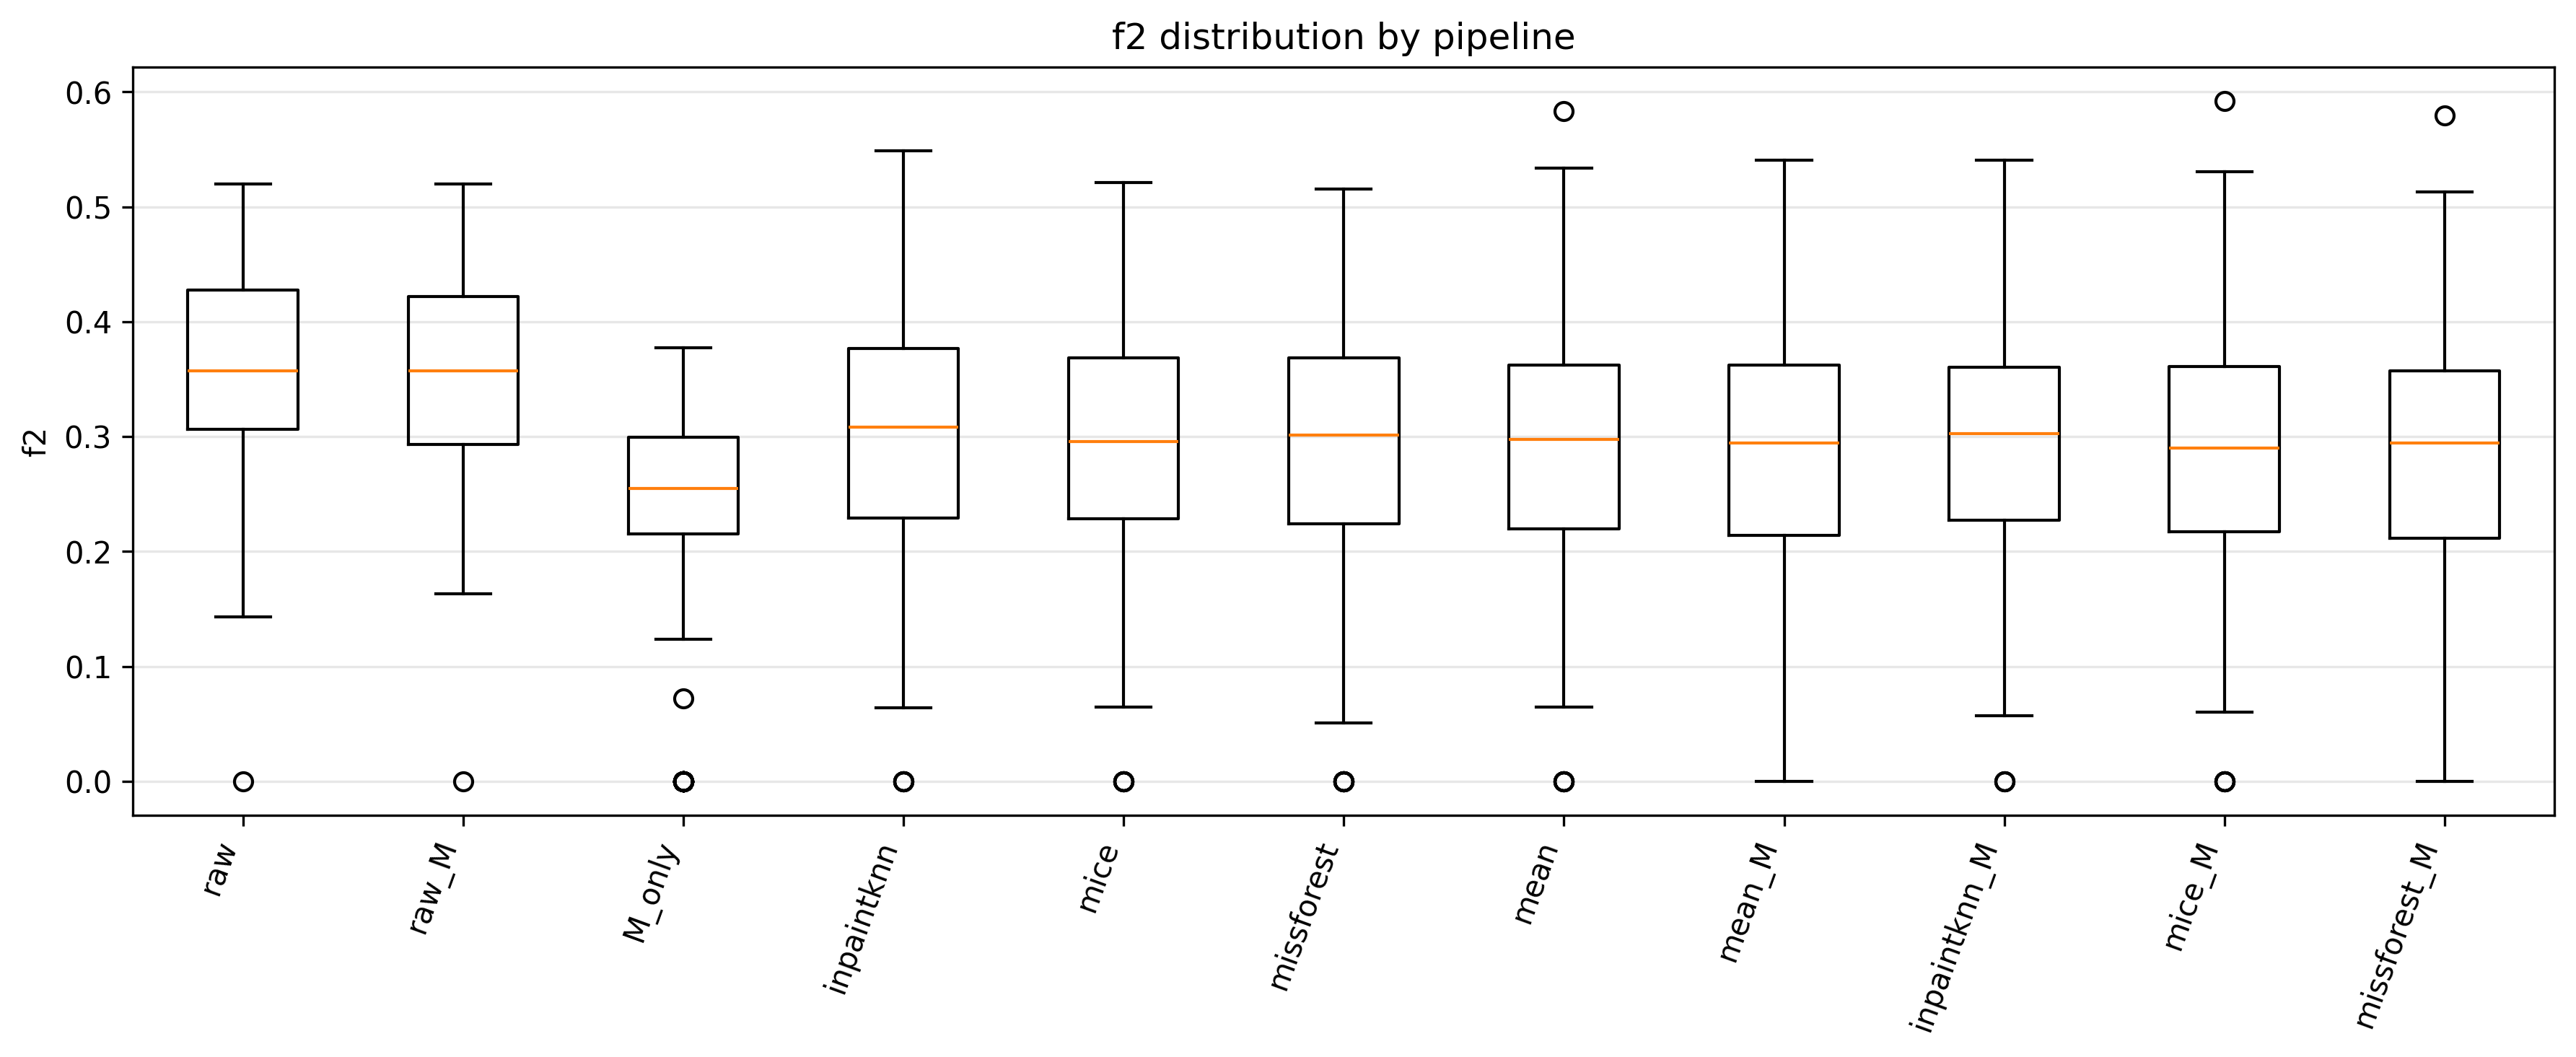

barplot_top_f2_gain_mean.png


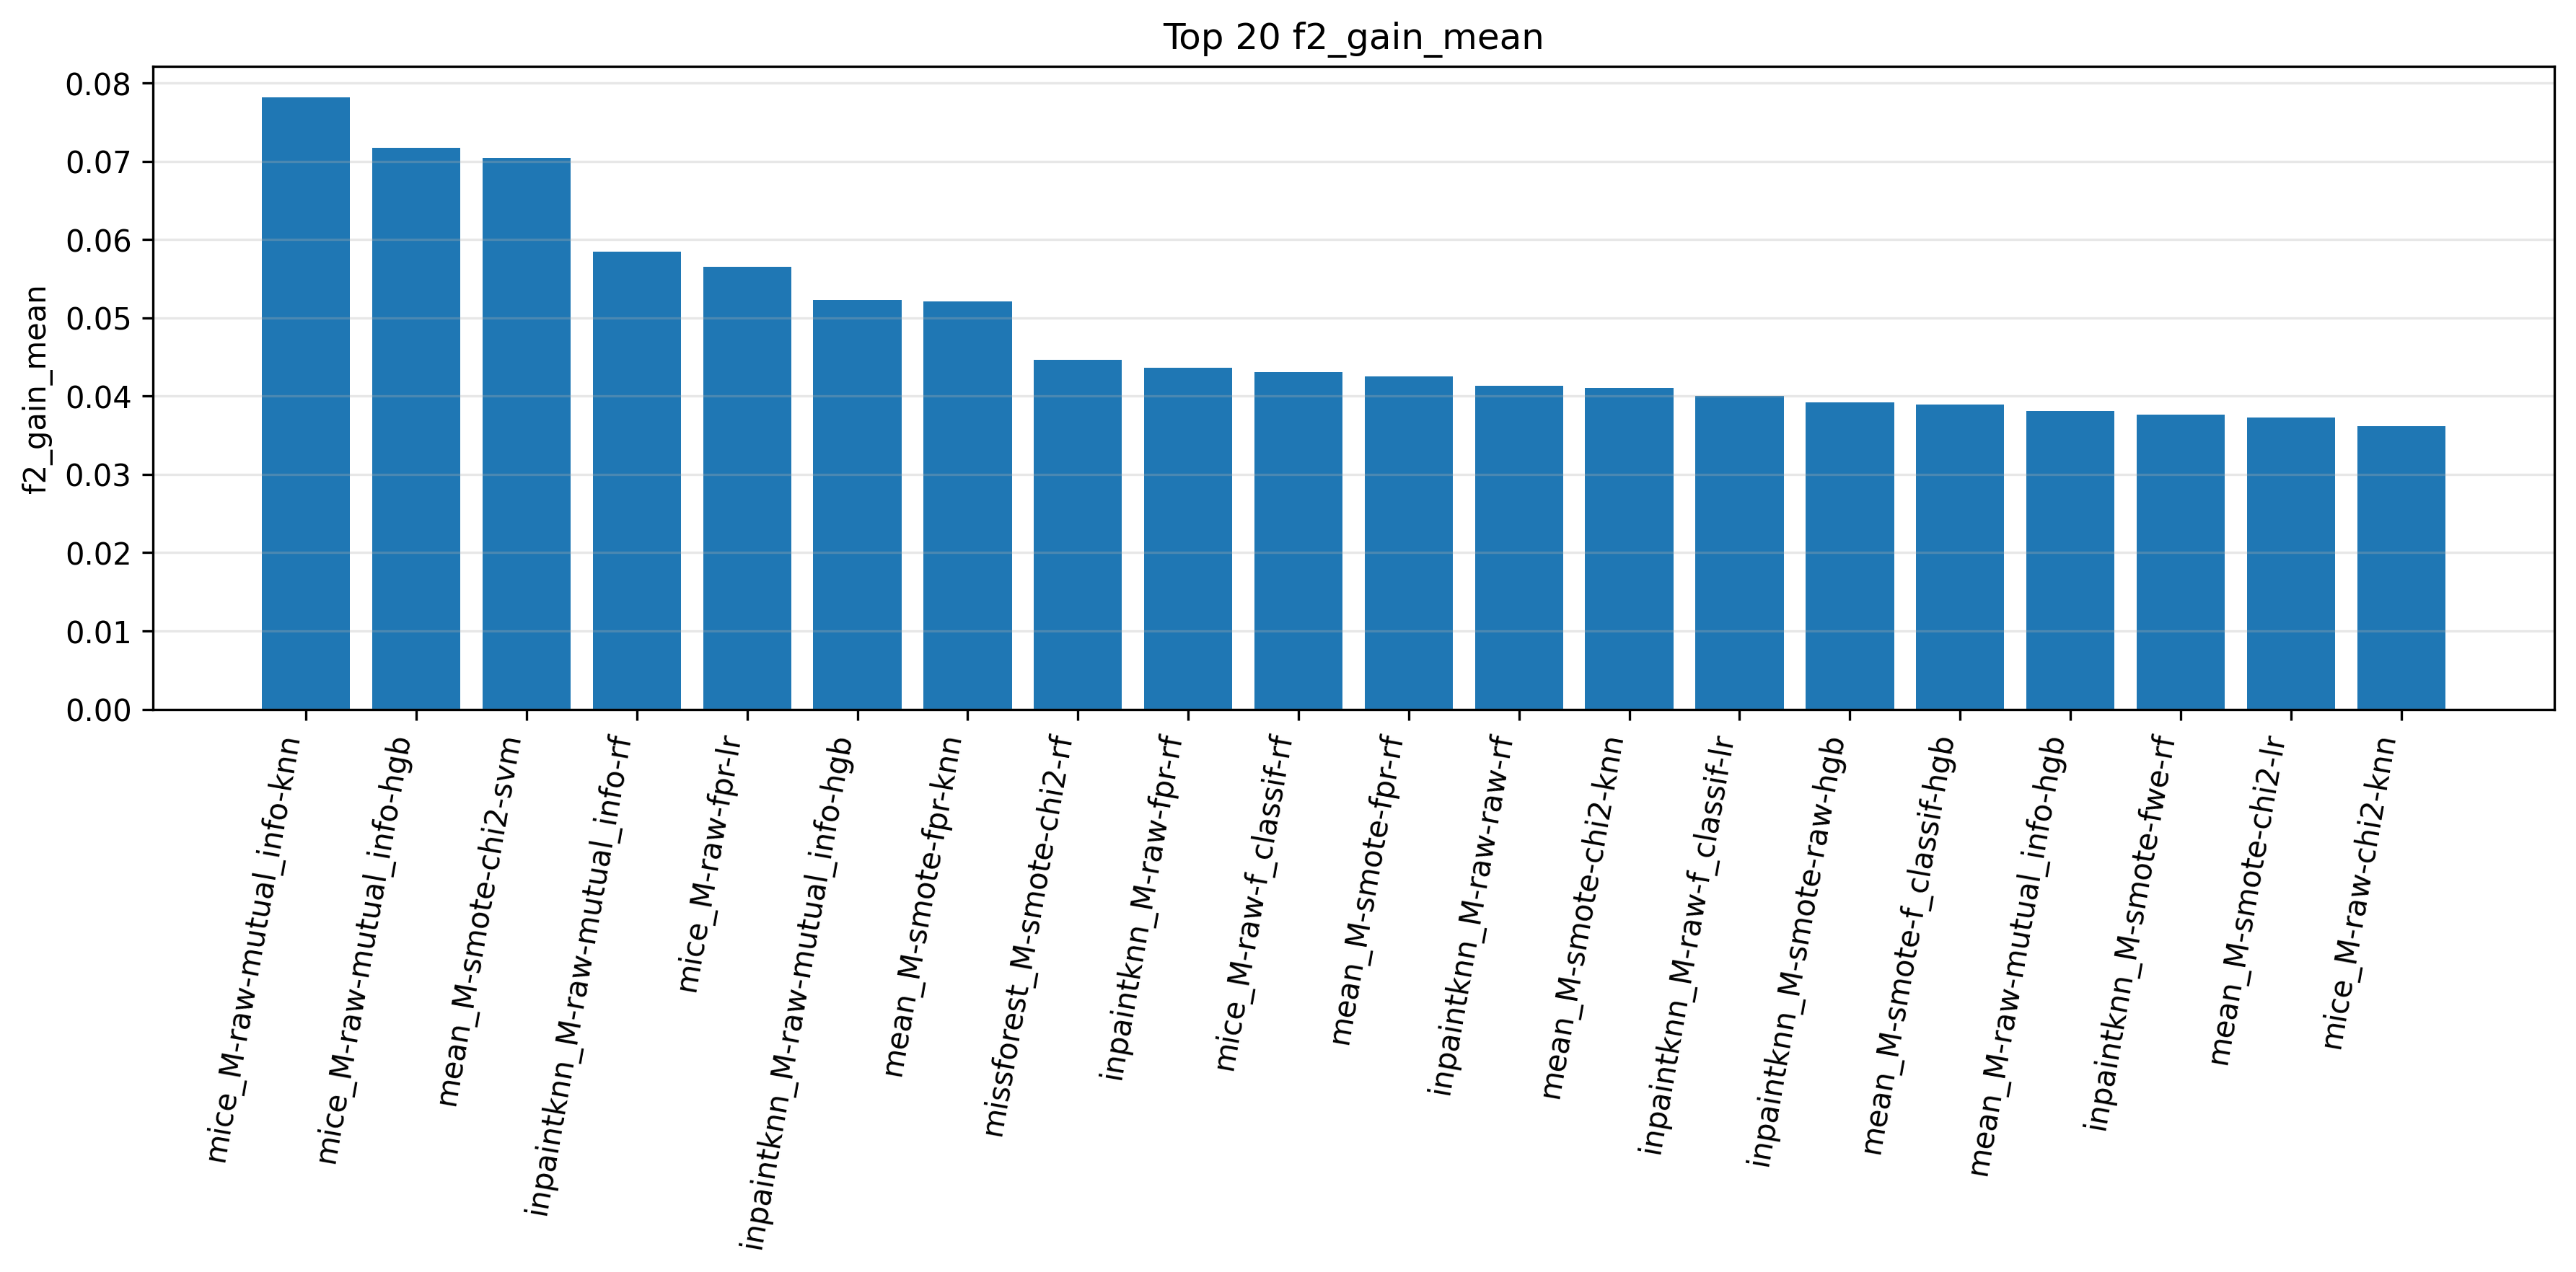

missing: roc_curves_top_models_by_f1.png
confusion_matrix_top_f1.png


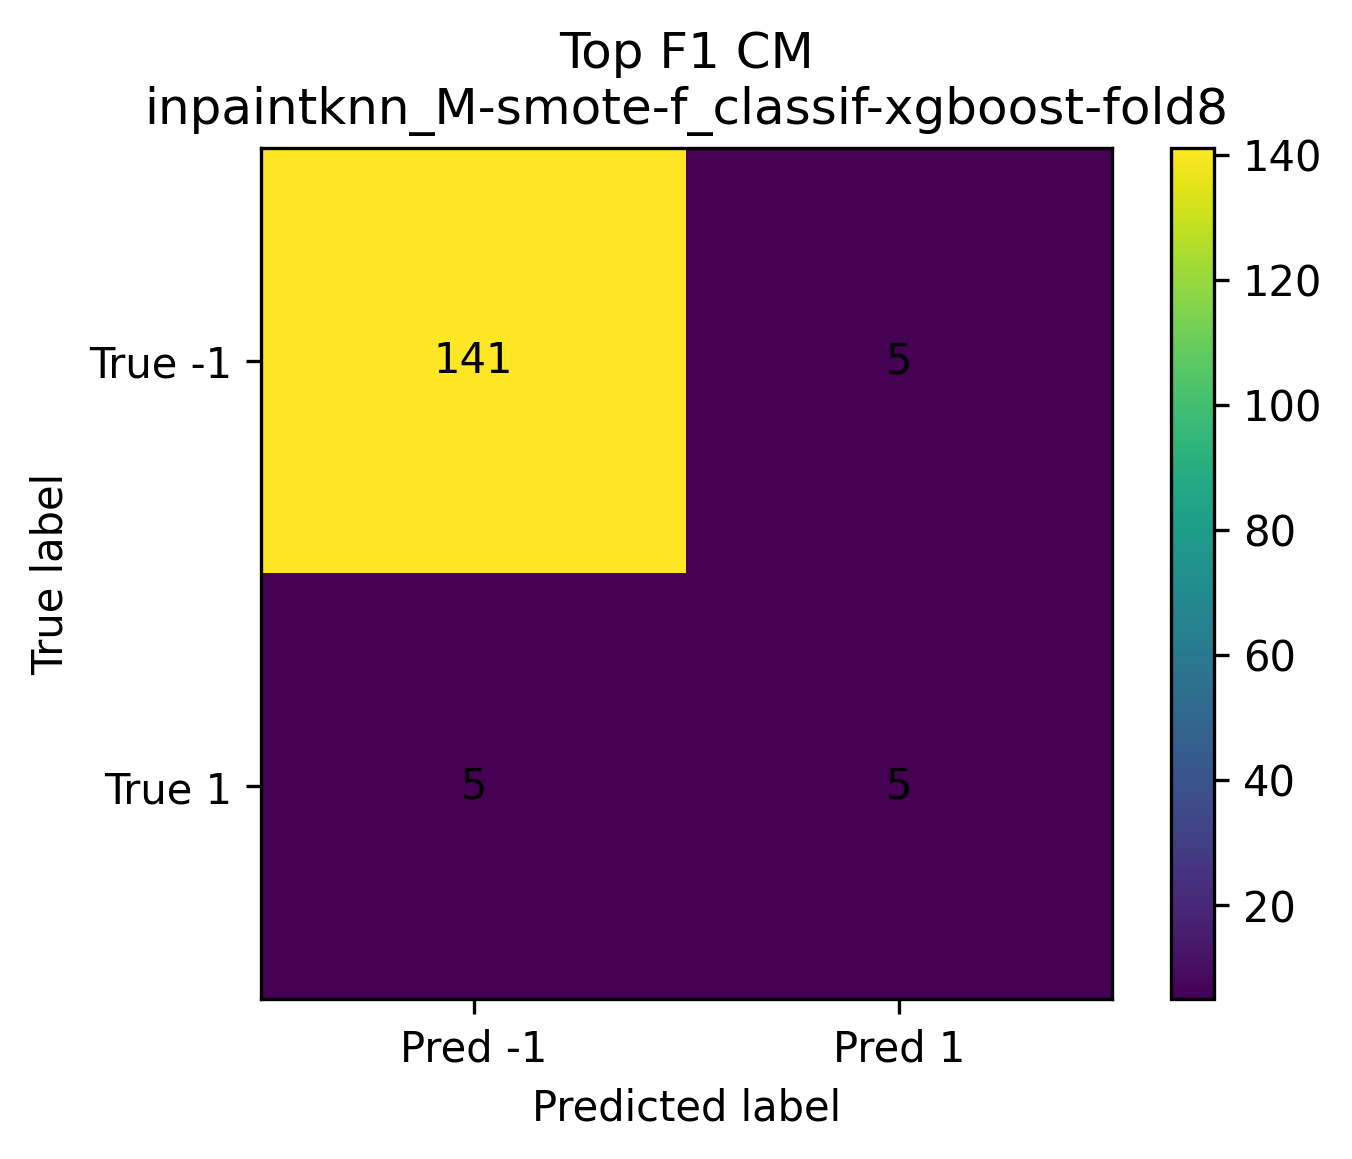

confusion_matrix_top_f2.png


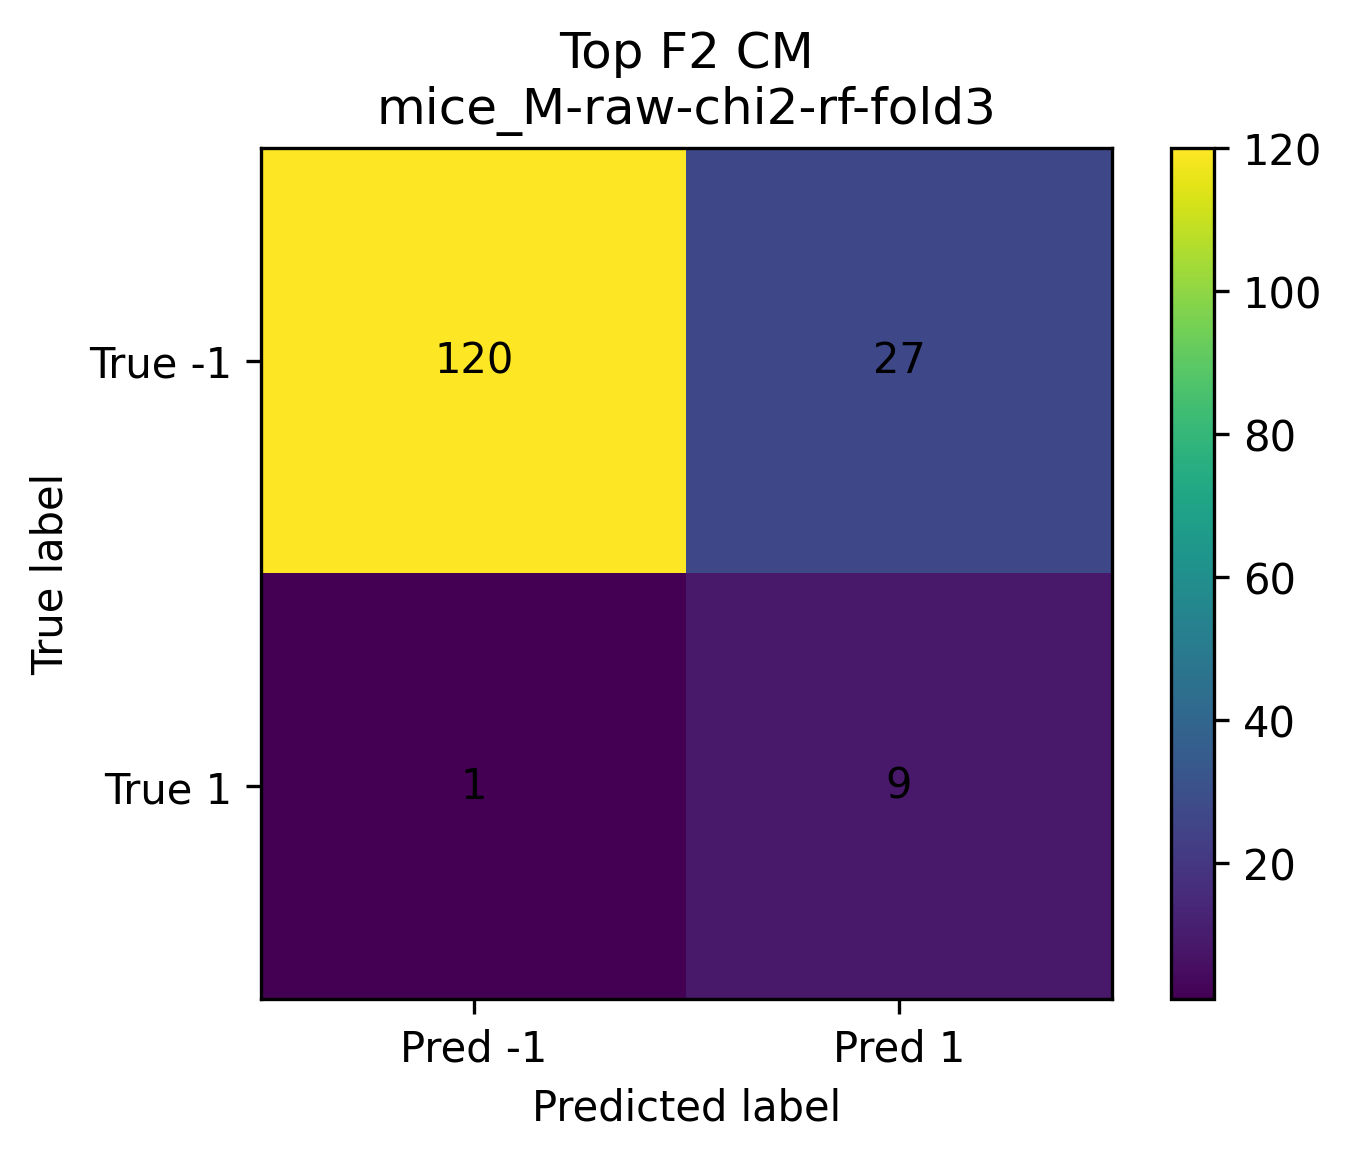

In [ ]:
if viz_dir.exists():
    preview_files = [
        "boxplot_f2_by_pipeline.png",
        "barplot_top_f2_gain_mean.png",
        "roc_curves_top_models_by_f1.png",
        "confusion_matrix_top_f1.png",
        "confusion_matrix_top_f2.png",
    ]

    for fname in preview_files:
        path = viz_dir / fname
        if path.exists():
            print(path.name)
            if IPythonImage is not None:
                display(IPythonImage(filename=str(path)))
            else:
                print(path)
        else:
            print(f"missing: {path.name}")
else:
    print(f"visualization directory not found: {viz_dir}")


## 20. 분석 완료 및 산출물 안내


In [67]:
print("\n" + "=" * 70)
print("분석 파이프라인 완료")
print("=" * 70)

print("\n결과 파일:")
print("  - analysis_results.xlsx: 모든 실험 결과, best_threshold 포함")
print("  - summary_by_pipeline.xlsx: pipeline별 요약")
print("  - m_feature_comparison_by_fold.xlsx: fold별 base vs M 비교")
print("  - m_feature_comparison_summary.xlsx: 평균 base vs M 비교")
print("  - simple_baseline_mean_lr_raw.xlsx: simple baseline")
print("  - error_details.xlsx: 스킵/에러 상세")
print("  - visualizations/: 시각화 결과 폴더")
print("    - confusion_matrix_top_f1.png")
print("    - confusion_matrix_top_f2.png")
print("    - roc_curves_top_models_by_f1.png")



분석 파이프라인 완료

결과 파일:
  - analysis_results.xlsx: 모든 실험 결과, best_threshold 포함
  - summary_by_pipeline.xlsx: pipeline별 요약
  - m_feature_comparison_by_fold.xlsx: fold별 base vs M 비교
  - m_feature_comparison_summary.xlsx: 평균 base vs M 비교
  - simple_baseline_mean_lr_raw.xlsx: simple baseline
  - error_details.xlsx: 스킵/에러 상세
  - visualizations/: 시각화 결과 폴더
    - confusion_matrix_top_f1.png
    - confusion_matrix_top_f2.png
    - roc_curves_top_models_by_f1.png
